# 연고관광 EDA

> 작성자: 전혜민 <br>
> 작성일: 26.07.10 <br>
> 목적: 연고 기반 방문객 전환 정책을 위한 2025년 국민여행조사 분석 <br>

이 노트북은 `연고관광_purpose.md`의 아이디어의 실효성을 확인하고, 현재 연고방문의 특징을 파악하기 위한 EDA를 수행한다. 연고방문이란 여행유형 중 2유형(국내 가족/친지/친구 방문 여행) 혹은 3유형(국내 단순 가족/친지/친구 방문)을 모두 아울러 말하며, 이중 2에 해당하는 여행을 연고여행이라 칭한다.

EDA는 다음과 같은 순서로 진행된다.

1. 연고방문의 규모
<!-- 2유형과 3유형이 전체 여행에서 차지하는 비중을 확인한다.-->
2. 연고방문의 특징
<!--분석 대상 변수: 일행수, 함께 여행한 일원 구성, 가구원수, 혼인 및 자녀여부, 차량보유여부, 성별, 연령, 월별 차이, 거주지역, 숙박여부, 여행일수, 총경비와 1인 지출비용, 주요교통수단(지역간, 지역내), 방문지역(시도단위, 시군구단위), 숙박시설-->
<!--연고방문(총합, 2유형, 3유형)vs1유형(국내관광/휴양여행)vs전체여행으로 나누어 살펴본다.-->
3. 연고여행의 특징 
<!--2유형에 해당하는 사람 중 다른 유형의 여행을 하지 않은 샘플만 골라서 분석을 진행한다(데이터의 신뢰성 확보). 해당 샘플의 개수를 먼저 제시하고 아래 분석 대상을 분석한다-->
<!-- 분석 대상 변수: 사전 예약 서비스 여부, 여행 지역 선택 이유, 참여활동, 여행 정보출처, 여행정보웹사이트, 함께 여행한 일원 구성, 반려동물 동반 여부, 출발전 지출비용, 여행 비용(대항목별 총액 비교), 여행 활동비 세부 지출 비용, 여행만족도, 항목별 만족도, 재방문 의향, 여행의 영향-->

In [1]:
from pathlib import Path
import sys


current_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / "src" / "path.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾을 수 없습니다. 프로젝트 내부에서 실행하세요."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.path import (  # noqa: E402
    NOTEBOOKS_DIR,
    OUTPUTS_DIR,
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    PROJECT_ROOT,
    RAW_DATA_DIR,
)


ROOT = PROJECT_ROOT

> 실행 환경: `.\tourism\Scripts\python.exe` (pandas, pyreadstat, matplotlib, seaborn, numpy, openpyxl, ipykernel 설치됨). 해당 환경의 `python3` 커널로 Restart & Run All.

## 0. 데이터 로드 및 구조 검증

In [2]:
import re
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- dataviz 스킬 팔레트 (references/palette.md) ---
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

# 카테고리 팔레트(고정 순서, CVD 안전 검증됨) — 다범주 항목에 순서대로 사용
CAT_PALETTE = [
    "#2a78d6",  # 1 blue
    "#1baf7a",  # 2 aqua
    "#eda100",  # 3 yellow
    "#008300",  # 4 green
    "#4a3aa7",  # 5 violet
    "#e34948",  # 6 red
    "#e87ba4",  # 7 magenta
    "#eb6834",  # 8 orange
]

# 그룹 비교(연고방문=강조, 그 외=중립)에 쓰는 고정 색
COLOR_HIGHLIGHT = "#2a78d6"       # 연고방문 / 2유형(연고여행) 강조색
COLOR_HIGHLIGHT_SUB = "#1c5cab"   # 3유형(단순방문) 등 강조색 보조 톤
COLOR_NEUTRAL_1 = "#898781"       # 1유형(국내 관광/휴양)
COLOR_NEUTRAL_2 = "#c3c2b7"       # 전체 여행

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "Malgun Gothic",   # 한글 폰트 (Windows 기본 고딕)
    "axes.unicode_minus": False,
    "font.size": 10.5,
})


def style_axis(ax):
    """차트 스파인·그리드 공통 마감."""
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.6, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


def pct_formatter(ax, axis="x"):
    fmt = mticker.PercentFormatter(decimals=0)
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)

In [3]:
SAV_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "y2025"
    / "2025년_국민여행조사_국내여행.SAV"
)

df, meta = pyreadstat.read_sav(SAV_PATH)
codebook = pd.read_csv(
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "y2025"
    / "national_travel_survey_codebook_2025.csv",
    encoding="utf-8-sig",
)

print("df.shape:", df.shape)
print("df['ID'].nunique():", df["ID"].nunique())
print("codebook rows:", len(codebook))

# --- 허용 컬럼 가드: codebook.csv에 없는 컬럼(=한글 파생 컬럼 등) 참조 방지 ---
ALLOWED_COLS = set(codebook["col_name"])


def assert_allowed(cols):
    if isinstance(cols, str):
        cols = [cols]
    disallowed = [c for c in cols if c not in ALLOWED_COLS]
    if disallowed:
        raise ValueError(f"codebook.csv에 없는(허용되지 않은) 컬럼 참조: {disallowed}")


def var_labels(col):
    """pyreadstat 메타에서 해당 컬럼의 {코드값: 라벨} 딕셔너리 반환 (라벨 앞뒤 공백 제거)."""
    assert_allowed(col)
    raw = meta.variable_value_labels.get(col, {})
    return {k: (v.strip() if isinstance(v, str) else v) for k, v in raw.items()}


def decode(series, col):
    """코드값 Series를 라벨 Series로 변환 (라벨 없는 값은 NaN)."""
    labels = var_labels(col)
    return series.map(labels)

df.shape: (52185, 2419)
df['ID'].nunique(): 52185
codebook rows: 1427


In [4]:
# --- 구조 가정 검증 ---
# 가정: "A1~A12 상세 문항은 D_TRA1(여행1차)에 대응하며, D_TRA1_CHECK가 그 진행 여부를 가리킨다"

print("D_TRA1_CHECK 값 분포:")
print(df["D_TRA1_CHECK"].value_counts(dropna=False))
print("\n※ 실측 결과: 'Y'/'' 두 값을 갖는 문자열 컬럼이며 1/0이 아니다 → 계획서의 `==1` 비교는 틀렸고 `=='Y'`를 써야 함")

check_cols = [f"D_TRA{t}_CHECK" for t in range(1, 7)]
n_filled = (df[check_cols] == "Y").sum(axis=1)
print("\n행당 채워진 D_TRA 슬롯 개수(D_TRA{t}_CHECK=='Y') 분포:")
print(n_filled.value_counts().sort_index())

print("\nD_TRA1_CASE notna 개수:", df["D_TRA1_CASE"].notna().sum(), " / D_TRA1_CHECK=='Y' 개수:", (df["D_TRA1_CHECK"] == "Y").sum())

a6_vs_num = df.loc[df["D_TRA1_CHECK"] == "Y", ["A6", "D_TRA1_NUM"]].dropna()
print(f"\n[D_TRA1_CHECK=='Y' 대상] A6 vs D_TRA1_NUM: n={len(a6_vs_num)}, "
      f"상관={a6_vs_num['A6'].corr(a6_vs_num['D_TRA1_NUM']):.3f}, "
      f"완전일치율={(a6_vs_num['A6'] == a6_vs_num['D_TRA1_NUM']).mean():.1%}")
print("→ A6(일행수)와 D_TRA1_NUM(여행1차 지출비용 포함 인원수)은 정의가 달라(일행 전체 vs 지출분담 인원) 완전 일치하진 않지만, "
      "A6·A9 등 A-계열 문항의 응답 유무는 D_TRA1_CHECK=='Y'와 사실상 동일하게 움직인다(아래 확인).")

a9_notna = df["A9"].notna()
check_y = df["D_TRA1_CHECK"] == "Y"
print(f"\nA9 응답자 수: {a9_notna.sum()}, D_TRA1_CHECK=='Y' 수: {check_y.sum()}, "
      f"교집합: {(a9_notna & check_y).sum()}, A9만 있고 CHECK!='Y'인 경우: {(a9_notna & ~check_y).sum()}")
print("→ A-계열 문항은 D_TRA1_CHECK=='Y'인 행에서 사실상 전량 응답됨을 확인. 이 컬럼을 2·3단계의 기준행 정의로 사용한다.")

# --- 분석 대상 "여행" 기준행 정의 ---
base = df[df["D_TRA1_CHECK"] == "Y"].copy()
print("\nbase(D_TRA1_CHECK=='Y') shape:", base.shape)

print("\nWT_DOM 결측/0 개수:", df["WT_DOM"].isna().sum(), "/", (df["WT_DOM"] == 0).sum())

D_TRA1_CHECK 값 분포:
D_TRA1_CHECK
     29456
Y    22729
Name: count, dtype: int64

※ 실측 결과: 'Y'/'' 두 값을 갖는 문자열 컬럼이며 1/0이 아니다 → 계획서의 `==1` 비교는 틀렸고 `=='Y'`를 써야 함

행당 채워진 D_TRA 슬롯 개수(D_TRA{t}_CHECK=='Y') 분포:
0    28197
1    23988
Name: count, dtype: int64

D_TRA1_CASE notna 개수: 26713  / D_TRA1_CHECK=='Y' 개수: 22729

[D_TRA1_CHECK=='Y' 대상] A6 vs D_TRA1_NUM: n=22729, 상관=0.189, 완전일치율=68.9%
→ A6(일행수)와 D_TRA1_NUM(여행1차 지출비용 포함 인원수)은 정의가 달라(일행 전체 vs 지출분담 인원) 완전 일치하진 않지만, A6·A9 등 A-계열 문항의 응답 유무는 D_TRA1_CHECK=='Y'와 사실상 동일하게 움직인다(아래 확인).

A9 응답자 수: 23988, D_TRA1_CHECK=='Y' 수: 22729, 교집합: 22729, A9만 있고 CHECK!='Y'인 경우: 1259
→ A-계열 문항은 D_TRA1_CHECK=='Y'인 행에서 사실상 전량 응답됨을 확인. 이 컬럼을 2·3단계의 기준행 정의로 사용한다.



base(D_TRA1_CHECK=='Y') shape: (22729, 2419)

WT_DOM 결측/0 개수: 0 / 0


In [5]:
# =========================================================================
# 가중(범주형 비율/빈도) / 비가중(연속형 분포) 헬퍼 — 1·2·3단계 공통 재사용
# =========================================================================
WEIGHT_COL = "WT_DOM"


def weighted_value_counts(data, col, weight_col=WEIGHT_COL, decode_labels=True, dropna=True):
    """단일 범주형 변수의 그룹별(가중) 비율(%) — 응답자 대비 100%."""
    assert_allowed(col)
    s = decode(data[col], col) if decode_labels else data[col]
    tmp = pd.DataFrame({"cat": s, "w": data[weight_col]})
    if dropna:
        tmp = tmp.dropna(subset=["cat"])
    grouped = tmp.groupby("cat", observed=True)["w"].sum()
    return (grouped / grouped.sum() * 100).sort_values(ascending=False)


def explode_multi(data, cols, weight_col=WEIGHT_COL, decode_labels=True):
    """다중응답 변수군(A2_1..A2_11 등)을 long format으로 변환."""
    assert_allowed(cols)
    long_df = data[cols + [weight_col]].melt(id_vars=[weight_col], value_vars=cols, value_name="code")
    long_df = long_df.dropna(subset=["code"])
    if decode_labels:
        labels = var_labels(cols[0])
        long_df["label"] = long_df["code"].map(labels)
    else:
        long_df["label"] = long_df["code"]
    return long_df.dropna(subset=["label"])


def weighted_multi_ratio(data, cols, weight_col=WEIGHT_COL, exclude_labels=None):
    """다중응답 항목별 선택 비율(%, 가중) — 분모=응답 표본 전체 가중합. 여러 개 선택 가능하므로 합이 100%를 넘을 수 있음."""
    long_df = explode_multi(data, cols, weight_col)
    if exclude_labels:
        long_df = long_df[~long_df["label"].isin(exclude_labels)]
    numer = long_df.groupby("label")[weight_col].sum()
    denom = data[weight_col].sum()
    return (numer / denom * 100).sort_values(ascending=False)


def weighted_multi_composition(data, cols, weight_col=WEIGHT_COL, exclude_labels=None):
    """다중응답 항목의 '언급 구성비'(그룹 내 전체 선택 합=100%, 가중) — 100% 누적 막대용."""
    long_df = explode_multi(data, cols, weight_col)
    if exclude_labels:
        long_df = long_df[~long_df["label"].isin(exclude_labels)]
    numer = long_df.groupby("label")[weight_col].sum()
    return (numer / numer.sum() * 100).sort_values(ascending=False)


def raw_describe(data, col):
    """연속형 변수 비가중 기술통계."""
    assert_allowed(col)
    return data[col].dropna().describe()


def raw_group_arrays(group_defs, col):
    """group_defs: {그룹명: DataFrame} → {그룹명: 결측 제외 numpy array} (비가중)."""
    assert_allowed(col)
    return {name: d[col].dropna().values for name, d in group_defs.items()}


def group_mean_series(group_defs, col):
    """group_defs: {그룹명: DataFrame} → 그룹별 비가중 평균 pd.Series (Likert 점수용, 9=해당없음 등은 사전에 결측 처리해서 전달)."""
    assert_allowed(col)
    return pd.Series({name: d[col].dropna().mean() for name, d in group_defs.items()})


# =========================================================================
# 플로팅 헬퍼 — dataviz 스킬 팔레트/스타일 적용
# =========================================================================
GROUP_COLOR_CYCLE = [COLOR_HIGHLIGHT, COLOR_NEUTRAL_1, COLOR_NEUTRAL_2, COLOR_HIGHLIGHT_SUB]


def plot_bar(series, title, xlabel="", ylabel="비중 (%, 가중)", highlight_idx=None, figsize=(8, 5), xrotation=0):
    fig, ax = plt.subplots(figsize=figsize)
    colors = [COLOR_HIGHLIGHT if (highlight_idx and i in highlight_idx) else COLOR_NEUTRAL_1
              for i in range(len(series))]
    ax.bar(series.index.astype(str), series.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    style_axis(ax)
    plt.xticks(rotation=xrotation, ha="right" if xrotation else "center")
    plt.tight_layout()
    plt.show()


def plot_stacked100(group_series, title, cat_order=None, top_n=None, other_label="기타", figsize_w=9.5):
    """group_series: {그룹명: pd.Series(index=카테고리, values=비중 %, 합계≈100)} → 100% 누적 가로 막대."""
    groups = list(group_series.keys())
    if cat_order is None:
        cat_order = list(group_series[groups[0]].sort_values(ascending=False).index)
        for g in groups[1:]:
            for c in group_series[g].index:
                if c not in cat_order:
                    cat_order.append(c)
    if top_n is not None and len(cat_order) > top_n:
        keep, rest = cat_order[:top_n], cat_order[top_n:]
        merged = {}
        for g in groups:
            s = group_series[g].reindex(keep).fillna(0.0)
            s[other_label] = group_series[g].reindex(rest).fillna(0.0).sum()
            merged[g] = s
        group_series, cat_order = merged, keep + [other_label]

    fig_h = max(2.2, 0.7 * len(groups) + 1)
    fig, ax = plt.subplots(figsize=(figsize_w, fig_h))
    bottoms = np.zeros(len(groups))
    for i, cat in enumerate(cat_order):
        vals = np.array([group_series[g].get(cat, 0.0) for g in groups], dtype=float)
        ax.barh(groups, vals, left=bottoms, color=CAT_PALETTE[i % len(CAT_PALETTE)],
                label=str(cat), edgecolor=SURFACE, linewidth=1)
        bottoms += vals
    ax.set_xlim(0, max(100, bottoms.max()))
    ax.set_xlabel("비중 (%, 가중)")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
    style_axis(ax)
    plt.tight_layout()
    plt.show()


def plot_grouped_bars(group_series, title, ylabel="", cat_order=None, top_n=None, figsize=(11, 5)):
    """group_series: {그룹명: pd.Series(index=카테고리, values=수치)} → 카테고리별 그룹 막대(나란히)."""
    groups = list(group_series.keys())
    if cat_order is None:
        cat_order = list(group_series[groups[0]].sort_values(ascending=False).index)
    if top_n is not None:
        cat_order = cat_order[:top_n]
    n_groups, n_cats = len(groups), len(cat_order)
    x = np.arange(n_cats)
    width = 0.8 / n_groups
    fig, ax = plt.subplots(figsize=figsize)
    for i, g in enumerate(groups):
        vals = [group_series[g].get(c, 0) for c in cat_order]
        ax.bar(x + i * width - width * (n_groups - 1) / 2, vals, width=width * 0.9,
               label=g, color=GROUP_COLOR_CYCLE[i % len(GROUP_COLOR_CYCLE)])
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cat_order], rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    style_axis(ax)
    plt.tight_layout()
    plt.show()


def plot_box(group_arrays, title, ylabel, log_scale=False, figsize=(7, 5)):
    """group_arrays: {그룹명: numpy array}(비가중 원자료) → 그룹별 box plot + 요약 출력."""
    groups = list(group_arrays.keys())
    data_list = [group_arrays[g] for g in groups]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(data_list, tick_labels=groups, patch_artist=True, showfliers=False, widths=0.5)
    for patch, c in zip(bp["boxes"], GROUP_COLOR_CYCLE):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor(INK_SECONDARY)
    for median in bp["medians"]:
        median.set_color(INK_PRIMARY)
    if log_scale:
        ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    style_axis(ax)
    plt.tight_layout()
    plt.show()
    for g in groups:
        arr = group_arrays[g]
        if len(arr):
            print(f"  {g}: n={len(arr):,}, 평균={np.mean(arr):,.0f}, 중앙값={np.median(arr):,.0f}")


def plot_radar(group_series, title, cat_order, figsize=(7, 7)):
    """group_series: {그룹명: pd.Series(index=카테고리, values=평균 점수)} → 레이더 차트."""
    groups = list(group_series.keys())
    n = len(cat_order)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    for i, g in enumerate(groups):
        vals = [group_series[g].get(c, np.nan) for c in cat_order]
        vals += vals[:1]
        color = GROUP_COLOR_CYCLE[i % len(GROUP_COLOR_CYCLE)]
        ax.plot(angles, vals, color=color, linewidth=2, label=g)
        ax.fill(angles, vals, color=color, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cat_order, fontsize=8)
    ax.set_title(title, y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), frameon=False)
    plt.tight_layout()
    plt.show()

In [6]:
# --- 방문지역 코드(SPOT, 5자리) → 시도/시군구명 매핑 ---
region_map = pd.read_csv(
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "national_travel_survey_region_code.csv",
    encoding="utf-8-sig",
)
region_map["spot_code"] = region_map["시도_코드"] * 1000 + region_map["시군구_코드"]

SIDO_MAP = region_map.drop_duplicates("시도_코드").set_index("시도_코드")["시도명"].to_dict()
SIGUNGU_MAP = dict(zip(region_map["spot_code"], region_map["시도명"] + " " + region_map["시군구명"]))


def decode_spot(series, level="sido"):
    """D_TRA1_1_SPOT(5자리 코드)을 시도명 또는 '시도 시군구'명으로 변환."""
    if level == "sido":
        return (series // 1000).map(SIDO_MAP)
    return series.map(SIGUNGU_MAP)


_spot_sample = base["D_TRA1_1_SPOT"].dropna()
print(f"D_TRA1_1_SPOT 응답 {len(_spot_sample)}건 중 시도 디코딩 실패: {decode_spot(_spot_sample, 'sido').isna().sum()}건, "
      f"시군구 디코딩 실패: {decode_spot(_spot_sample, 'sigungu').isna().sum()}건 "
      "(구 미분리 특별·광역시 코드 등 일부는 시군구명 매핑에서 빠질 수 있음)")

D_TRA1_1_SPOT 응답 22729건 중 시도 디코딩 실패: 0건, 시군구 디코딩 실패: 0건 (구 미분리 특별·광역시 코드 등 일부는 시군구명 매핑에서 빠질 수 있음)


## 1. 연고방문의 규모 분석

2유형(연고여행)·3유형(단순 연고방문)이 전체 국내여행에서 차지하는 비중을 가중치(`WT_DOM`) 기준으로 확인한다. 분석 단위는 `df` 전체 행(응답자의 해당 회차 여행 횟수 요약치 `SA1_1~5`).

In [7]:
SA1_COLS = [f"SA1_{i}" for i in range(1, 6)]
MON_EXP_COLS = [f"MON_EXP_{i}" for i in range(1, 6)]
assert_allowed(SA1_COLS + MON_EXP_COLS)

TYPE_LABELS = {
    1: "1유형: 관광/휴양",
    2: "2유형: 가족/친지/친구 방문(연고여행)",
    3: "3유형: 단순 가족/친지/친구 방문",
    4: "4유형: 출장/업무(관광 포함)",
    5: "5유형: 단순 출장/업무",
}

# 유형별 가중 여행량(SA1_i * WT_DOM의 합)
weighted_trip_volume = pd.Series({
    TYPE_LABELS[i]: (df[f"SA1_{i}"] * df[WEIGHT_COL]).sum() for i in range(1, 6)
})
total_weighted_trips = weighted_trip_volume.sum()
trip_share = weighted_trip_volume / total_weighted_trips * 100

yeongo_labels = [TYPE_LABELS[2], TYPE_LABELS[3]]
yeongo_total = weighted_trip_volume[yeongo_labels].sum()
yeongo_share = yeongo_total / total_weighted_trips * 100
yeongo_trip_only_share = weighted_trip_volume[TYPE_LABELS[2]] / total_weighted_trips * 100

# 응답자 기준 유형별 경험률(MON_EXP_i==1(예)의 가중 비율)
total_weight = df[WEIGHT_COL].sum()
exp_rate = pd.Series({
    TYPE_LABELS[i]: df.loc[df[f"MON_EXP_{i}"] == 1, WEIGHT_COL].sum() / total_weight * 100
    for i in range(1, 6)
})

summary_table = pd.DataFrame({
    "가중 여행량(횟수)": weighted_trip_volume.round(0),
    "여행량 비중(%)": trip_share.round(2),
    "경험률(%, 응답자 기준)": exp_rate.round(2),
})
print(summary_table)
print(f"\n연고방문(2+3유형) 여행량 비중: {yeongo_share:.2f}%")
print(f"연고여행(2유형 단독) 여행량 비중: {yeongo_trip_only_share:.2f}%")

                         가중 여행량(횟수)  여행량 비중(%)  경험률(%, 응답자 기준)
1유형: 관광/휴양              217286531.0      72.21           37.79
2유형: 가족/친지/친구 방문(연고여행)   37525420.0      12.47            6.65
3유형: 단순 가족/친지/친구 방문      32351011.0      10.75            5.49
4유형: 출장/업무(관광 포함)         6486739.0       2.16            1.13
5유형: 단순 출장/업무             7259606.0       2.41            1.21

연고방문(2+3유형) 여행량 비중: 23.22%
연고여행(2유형 단독) 여행량 비중: 12.47%


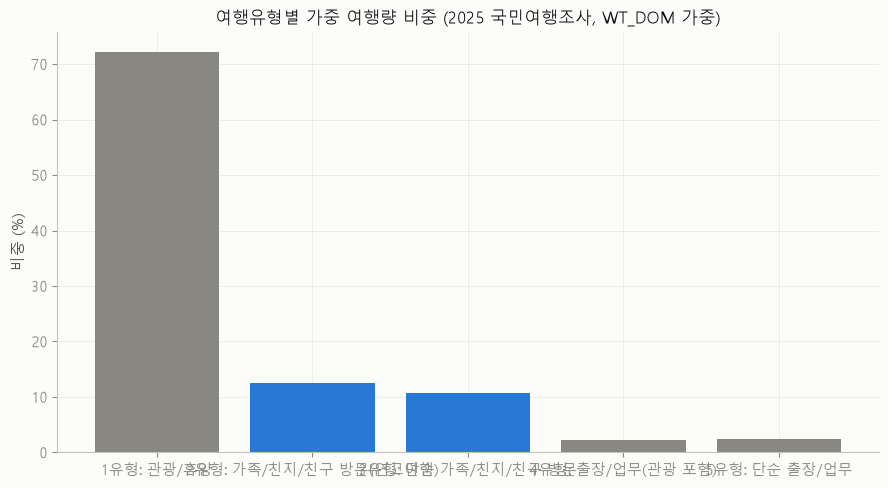

In [8]:
# 시각화 1: 유형 1~5별 가중 여행량(2·3유형 강조)
plot_bar(
    trip_share,
    title="여행유형별 가중 여행량 비중 (2025 국민여행조사, WT_DOM 가중)",
    ylabel="비중 (%)",
    highlight_idx={1, 2},
    figsize=(9, 5),
)

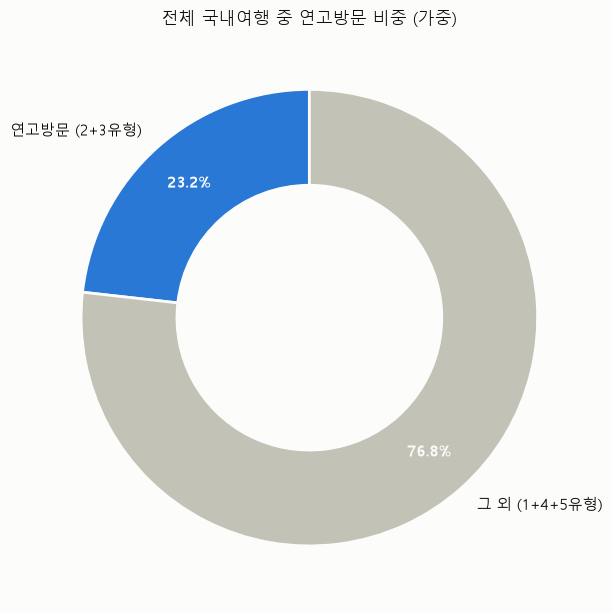

In [9]:
# 시각화 2: 연고방문(2+3유형) vs 그 외(1+4+5유형) 비중
other_share = 100 - yeongo_share
split_series = pd.Series({"연고방문 (2+3유형)": yeongo_share, "그 외 (1+4+5유형)": other_share})

fig, ax = plt.subplots(figsize=(6.5, 6.5))
colors = [COLOR_HIGHLIGHT, COLOR_NEUTRAL_2]
wedges, _, autotexts = ax.pie(
    split_series.values,
    labels=split_series.index,
    colors=colors,
    autopct="%.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor=SURFACE, linewidth=2),
    pctdistance=0.79,
    textprops={"color": INK_PRIMARY, "fontsize": 10.5},
)
for t in autotexts:
    t.set_color(SURFACE)
    t.set_fontweight("bold")
ax.set_title("전체 국내여행 중 연고방문 비중 (가중)")
plt.tight_layout()
plt.show()

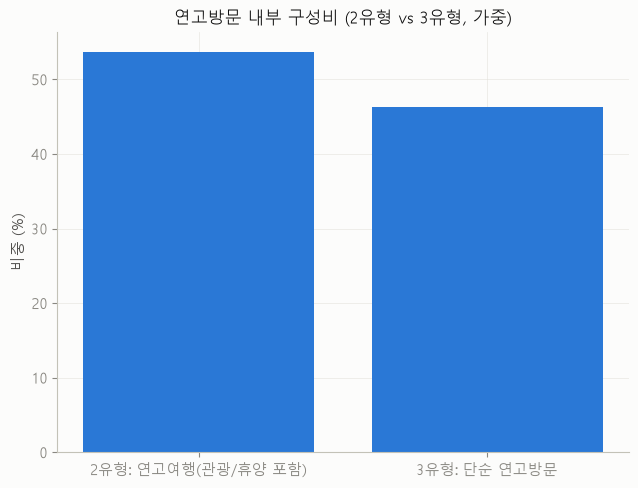

In [10]:
# 시각화 3: 연고방문 내부 구성비 — 2유형(연고여행) vs 3유형(단순방문)
inner_share = pd.Series({
    "2유형: 연고여행(관광/휴양 포함)": weighted_trip_volume[TYPE_LABELS[2]] / yeongo_total * 100,
    "3유형: 단순 연고방문": weighted_trip_volume[TYPE_LABELS[3]] / yeongo_total * 100,
})
plot_bar(
    inner_share,
    title="연고방문 내부 구성비 (2유형 vs 3유형, 가중)",
    ylabel="비중 (%)",
    highlight_idx={0, 1},
    figsize=(6.5, 5),
)

**해석**: 연고방문(2+3유형)은 전체 국내여행의 상당 비중을 차지하는 규모 있는 여행군이다. 그중 다수가 관광/휴양 활동이 결합되지 않은 3유형(단순 방문)에 쏠려 있다면, "연고 방문객을 소비·체험 방문객으로 전환"하려는 정책 개입의 여지(=아직 지역 소비로 이어지지 않는 규모)가 그만큼 크다는 뜻이다.

## 2. 연고방문의 특징 분석

분석 단위는 0단계에서 정의한 `base`(`D_TRA1_CHECK=='Y'`), 그룹 변수는 `D_TRA1_CASE`다.

- **G1 = 1유형** (`D_TRA1_CASE==1`, 국내 관광/휴양)
- **G2 = 연고방문** (`D_TRA1_CASE.isin([2,3])`, 2·3유형 합산)
- **G3 = 전체 여행** (`base` 전체, 유형 무관)

범주형 변수의 그룹별 비율은 `WT_DOM` 가중, 연속형 변수(일행수·가구원수·여행일수·경비 등)의 box plot·평균은 **비가중 원자료** 기준이다.

In [11]:
g1 = base[base["D_TRA1_CASE"] == 1]
g2 = base[base["D_TRA1_CASE"].isin([2, 3])]
g3 = base

groups2 = {"1유형(관광/휴양)": g1, "연고방문(2+3유형)": g2, "전체 여행": g3}
# 연고방문 내부 하위분해(2유형/3유형)도 병기용으로 준비
g2_sub = {"연고여행(2유형)": base[base["D_TRA1_CASE"] == 2], "단순 연고방문(3유형)": base[base["D_TRA1_CASE"] == 3]}

n_table = pd.DataFrame({
    "비가중 N": {k: len(v) for k, v in groups2.items()},
    "가중 합계": {k: v[WEIGHT_COL].sum() for k, v in groups2.items()},
})
print(n_table)

             비가중 N         가중 합계
1유형(관광/휴양)   18447  1.986409e+08
연고방문(2+3유형)   3689  3.497366e+07
전체 여행        22729  2.393125e+08


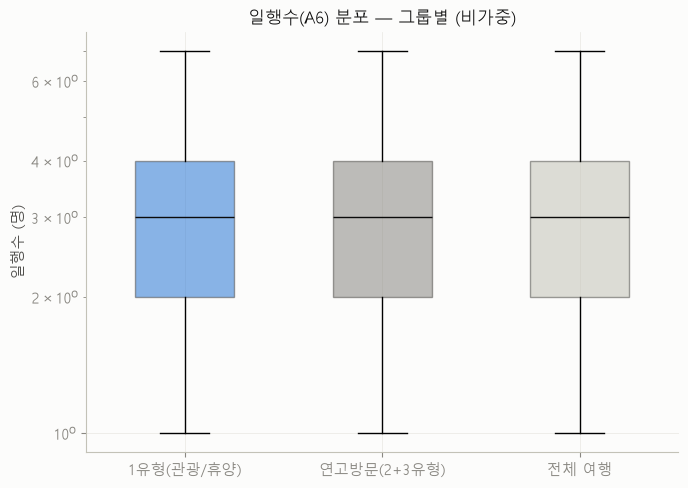

  1유형(관광/휴양): n=18,447, 평균=4, 중앙값=3
  연고방문(2+3유형): n=3,689, 평균=3, 중앙값=3
  전체 여행: n=22,729, 평균=4, 중앙값=3


In [12]:
# 일행수(A6) — 그룹별 box plot (비가중)
assert_allowed("A6")
plot_box(raw_group_arrays(groups2, "A6"), "일행수(A6) 분포 — 그룹별 (비가중)", "일행수 (명)", log_scale=True)

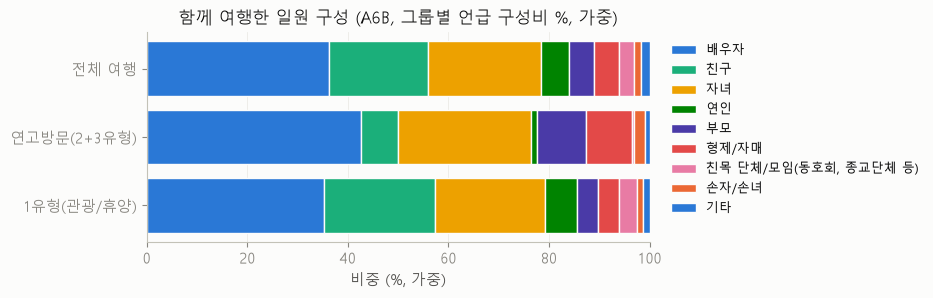

In [13]:
# 함께 여행한 일원 구성(A6B_1~12) — 그룹별 구성비 100% 누적 막대 (가중)
A6B_COLS = [f"A6B_{i}" for i in range(1, 13)]
assert_allowed(A6B_COLS)

a6b_composition = {name: weighted_multi_composition(d, A6B_COLS) for name, d in groups2.items()}
plot_stacked100(a6b_composition, "함께 여행한 일원 구성 (A6B, 그룹별 언급 구성비 %, 가중)", top_n=8)

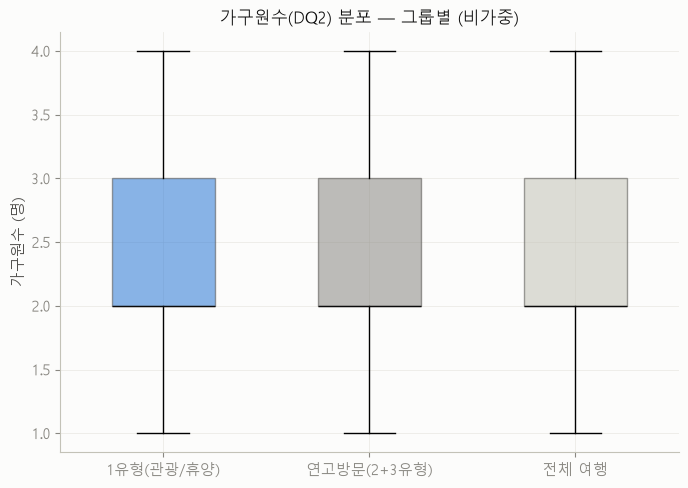

  1유형(관광/휴양): n=18,447, 평균=2, 중앙값=2
  연고방문(2+3유형): n=3,689, 평균=2, 중앙값=2
  전체 여행: n=22,729, 평균=2, 중앙값=2


In [14]:
# 가구원수(DQ2) — 그룹별 box plot (비가중)
assert_allowed("DQ2")
plot_box(raw_group_arrays(groups2, "DQ2"), "가구원수(DQ2) 분포 — 그룹별 (비가중)", "가구원수 (명)")

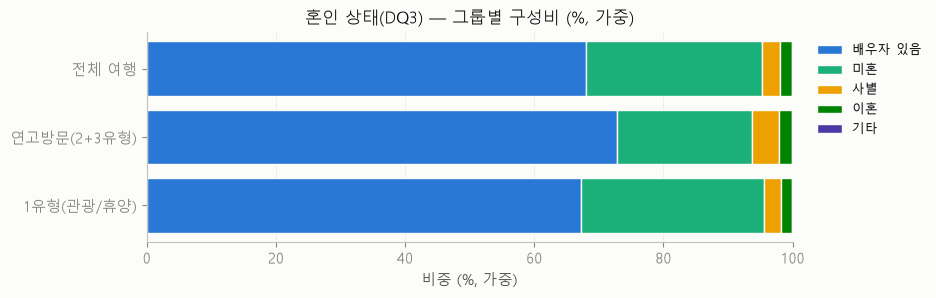

In [15]:
# 혼인 상태(DQ3) — 그룹별 100% 누적 막대 (가중)
assert_allowed("DQ3")
dq3_by_group = {name: weighted_value_counts(d, "DQ3") for name, d in groups2.items()}
plot_stacked100(dq3_by_group, "혼인 상태(DQ3) — 그룹별 구성비 (%, 가중)")

DQ3A_1 고유값: <StringArray>
['Y', '']
Length: 2, dtype: str
DQ3A 해당 응답자(dq3a_asked): 38080, 그중 동거 자녀/손자 있음: 15406


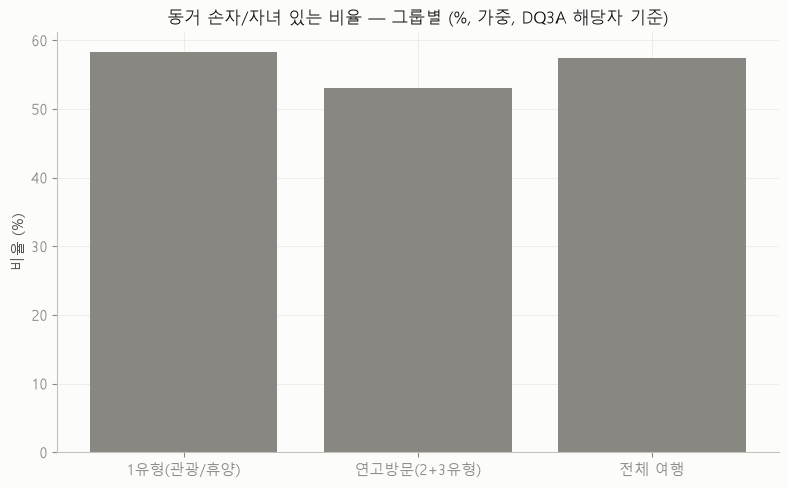

In [16]:
# 자녀(동거 손자/자녀) 여부 — DQ3A_1~4에서 파생
# DQ3A_1은 D_TRA1_CHECK와 동일하게 'Y'/''(빈 문자열) 코딩의 체크박스형 변수임을 확인 (계획서의 "없음(1)" 가정과 다름)
DQ3A_COLS = ["DQ3A_1", "DQ3A_2", "DQ3A_3", "DQ3A_4"]
assert_allowed(DQ3A_COLS)
print("DQ3A_1 고유값:", df["DQ3A_1"].unique())

child_count = df[["DQ3A_2", "DQ3A_3", "DQ3A_4"]].sum(axis=1, skipna=True)
dq3a_asked = df["DQ3A_2"].notna() | (df["DQ3A_1"] == "Y")  # DQ3(혼인상태)==미혼인 경우 항목 자체가 스킵됨
has_cohab_child = pd.Series(np.where(df["DQ3A_1"] == "Y", False, child_count > 0), index=df.index)
has_cohab_child = has_cohab_child.where(dq3a_asked)  # 해당없음(미혼 등)은 결측 처리

print(f"DQ3A 해당 응답자(dq3a_asked): {dq3a_asked.sum()}, 그중 동거 자녀/손자 있음: {has_cohab_child.sum(skipna=True):.0f}")

df["_has_cohab_child"] = has_cohab_child
groups2_child = {name: d.assign(_has_cohab_child=has_cohab_child.loc[d.index]) for name, d in groups2.items()}

child_ratio = pd.Series({
    name: (d.loc[d["_has_cohab_child"].notna(), WEIGHT_COL] * d.loc[d["_has_cohab_child"].notna(), "_has_cohab_child"]).sum()
          / d.loc[d["_has_cohab_child"].notna(), WEIGHT_COL].sum() * 100
    for name, d in groups2_child.items()
})
plot_bar(child_ratio, "동거 손자/자녀 있는 비율 — 그룹별 (%, 가중, DQ3A 해당자 기준)", ylabel="비율 (%)")

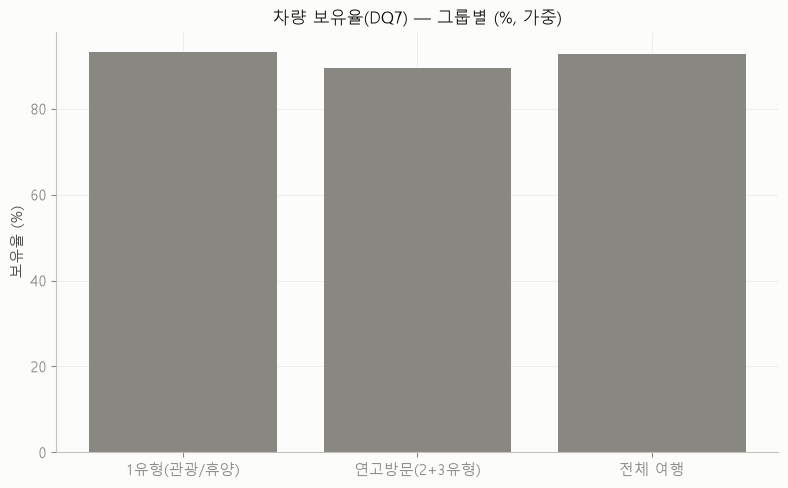

In [17]:
# 차량 보유 여부(DQ7) — 그룹별 보유율 (%, 가중)
assert_allowed("DQ7")
car_own_ratio = pd.Series({
    name: d.loc[d["DQ7"] == 1, WEIGHT_COL].sum() / d.loc[d["DQ7"].notna(), WEIGHT_COL].sum() * 100
    for name, d in groups2.items()
})
plot_bar(car_own_ratio, "차량 보유율(DQ7) — 그룹별 (%, 가중)", ylabel="보유율 (%)")

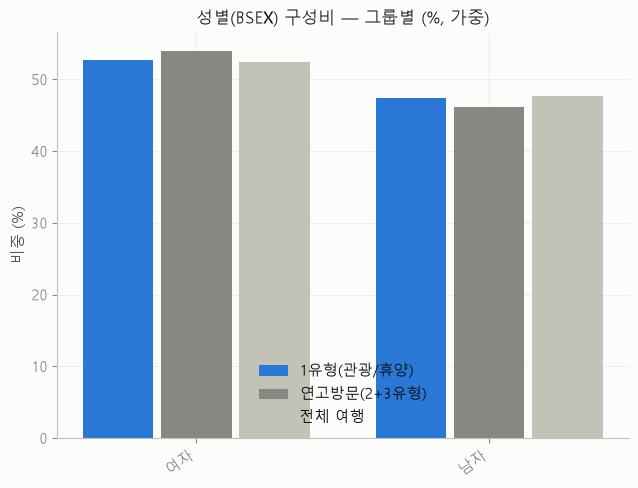

In [18]:
# 성별(BSEX) — 그룹별 비율 막대 (가중)
assert_allowed("BSEX")
bsex_by_group = {name: weighted_value_counts(d, "BSEX") for name, d in groups2.items()}
plot_grouped_bars(bsex_by_group, "성별(BSEX) 구성비 — 그룹별 (%, 가중)", ylabel="비중 (%)", figsize=(6.5, 5))

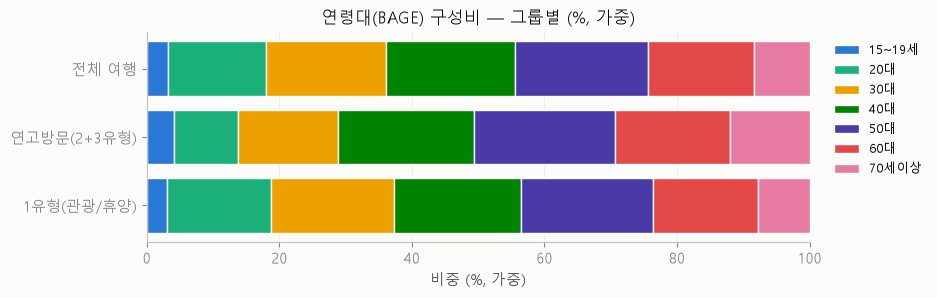

In [19]:
# 연령대(BAGE) — 그룹별 100% 누적 막대 (7개 연령대, 가중)
assert_allowed("BAGE")
age_order = ["15~19세", "20대", "30대", "40대", "50대", "60대", "70세이상"]
bage_by_group = {name: weighted_value_counts(d, "BAGE") for name, d in groups2.items()}
plot_stacked100(bage_by_group, "연령대(BAGE) 구성비 — 그룹별 (%, 가중)", cat_order=age_order)

In [20]:
bage_by_group

{'1유형(관광/휴양)': cat
 50대       19.806465
 40대       19.170557
 30대       18.642808
 60대       15.896790
 20대       15.697022
 70세이상      7.793124
 15~19세     2.993235
 Name: w, dtype: float64,
 '연고방문(2+3유형)': cat
 50대       21.316607
 40대       20.566395
 60대       17.308064
 30대       15.116068
 70세이상     11.977924
 20대        9.658193
 15~19세     4.056749
 Name: w, dtype: float64,
 '전체 여행': cat
 50대       20.023721
 40대       19.422238
 30대       18.160509
 60대       16.041289
 20대       14.816178
 70세이상      8.379830
 15~19세     3.156235
 Name: w, dtype: float64}

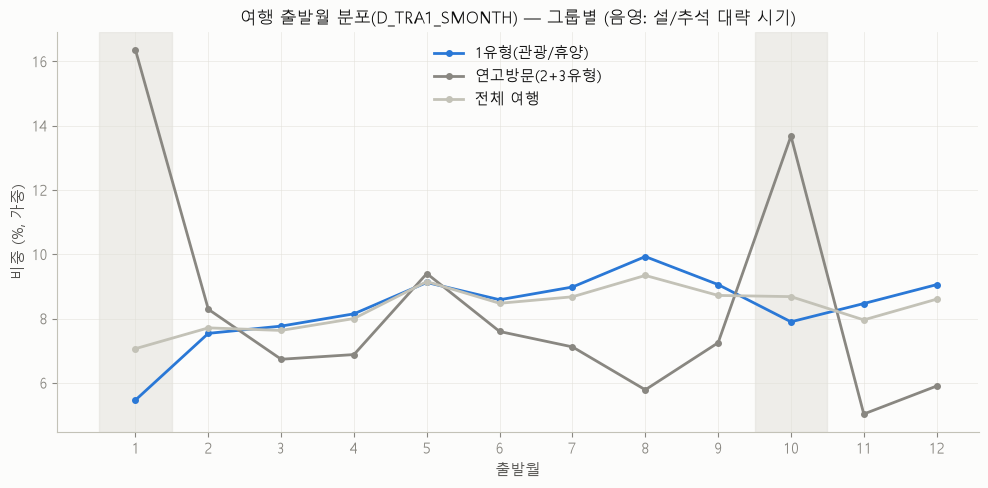

In [21]:
# 월별 분포(D_TRA1_SMONTH) — 그룹별 라인 차트 (1~12월, 가중, 계절성/명절월 비교)
assert_allowed("D_TRA1_SMONTH")
month_by_group = {}
for name, d in groups2.items():
    w = d.groupby("D_TRA1_SMONTH")[WEIGHT_COL].sum()
    month_by_group[name] = (w / w.sum() * 100).reindex(range(1, 13), fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, s) in enumerate(month_by_group.items()):
    ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=2,
            color=GROUP_COLOR_CYCLE[i % len(GROUP_COLOR_CYCLE)], label=name)
ax.axvspan(0.5, 1.5, color=GRIDLINE, alpha=0.5, zorder=0)   # 설 연휴(1월)
ax.axvspan(9.5, 10.5, color=GRIDLINE, alpha=0.5, zorder=0)   # 추석 연휴(10월)
ax.set_xticks(range(1, 13))
ax.set_xlabel("출발월")
ax.set_ylabel("비중 (%, 가중)")
ax.set_title("여행 출발월 분포(D_TRA1_SMONTH) — 그룹별 (음영: 설/추석 대략 시기)")
ax.legend(frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()

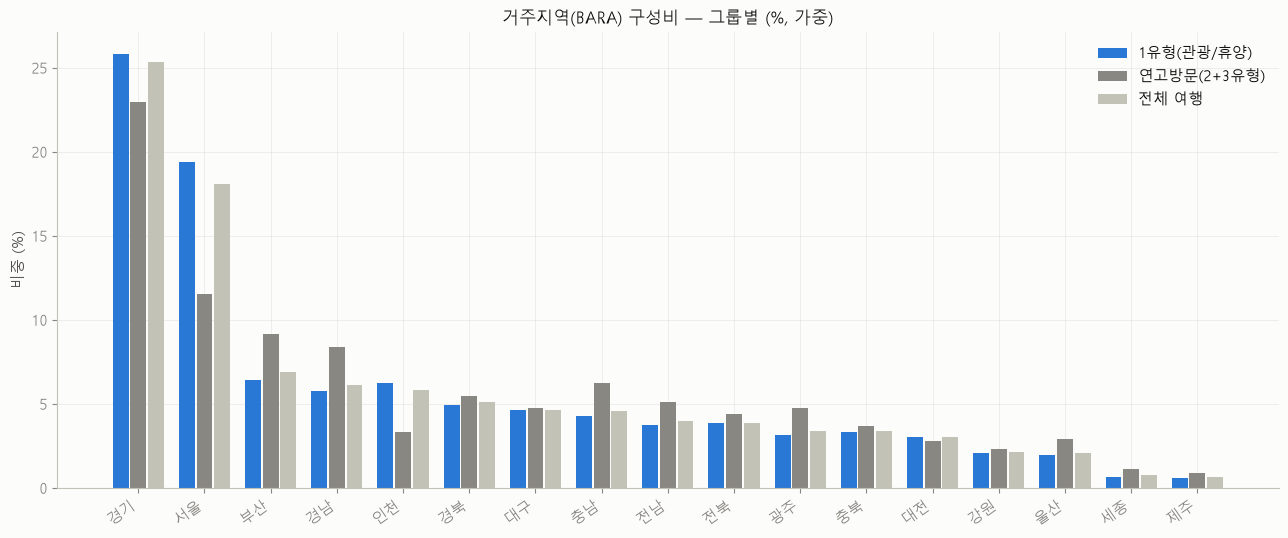

In [22]:
# 거주지역(BARA) — 그룹별 상위 지역 막대 (가중)
assert_allowed("BARA")
bara_by_group = {name: weighted_value_counts(d, "BARA") for name, d in groups2.items()}
plot_grouped_bars(bara_by_group, "거주지역(BARA) 구성비 — 그룹별 (%, 가중)", ylabel="비중 (%)",
                   cat_order=list(bara_by_group["전체 여행"].sort_values(ascending=False).index), figsize=(13, 5.5))

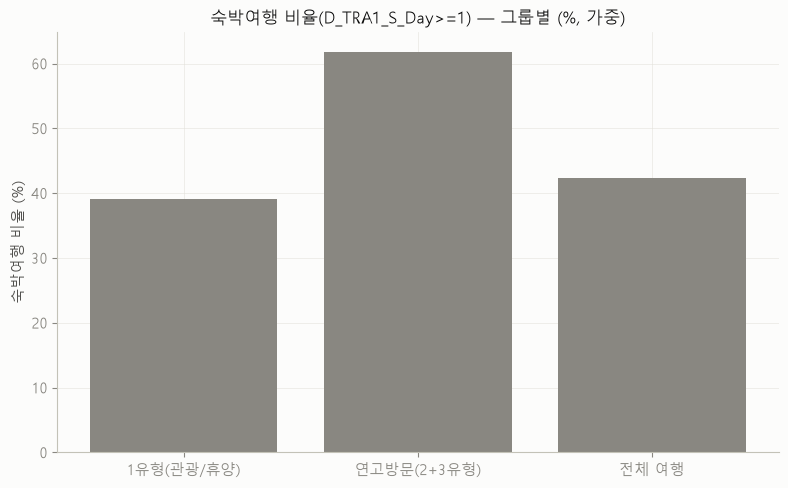

In [23]:
# 숙박 여부(파생: D_TRA1_S_Day >= 1 → 숙박여행, ==0 → 당일여행) — 그룹별 숙박여행 비율 (%, 가중)
assert_allowed("D_TRA1_S_Day")
overnight_ratio = pd.Series({
    name: d.loc[d["D_TRA1_S_Day"] >= 1, WEIGHT_COL].sum() / d.loc[d["D_TRA1_S_Day"].notna(), WEIGHT_COL].sum() * 100
    for name, d in groups2.items()
})
plot_bar(overnight_ratio, "숙박여행 비율(D_TRA1_S_Day>=1) — 그룹별 (%, 가중)", ylabel="숙박여행 비율 (%)")

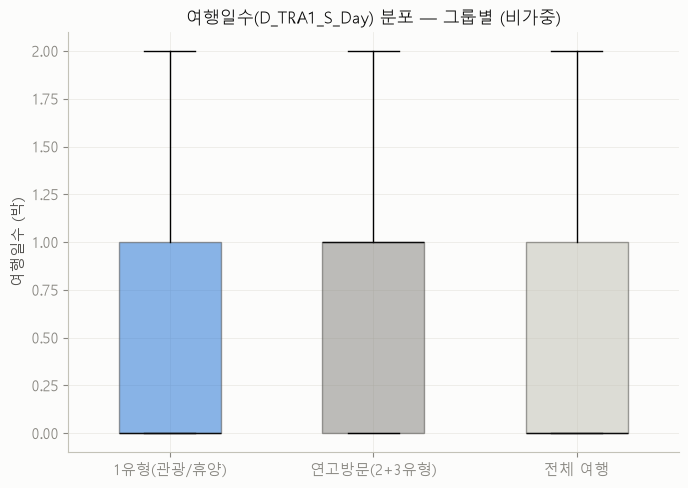

  1유형(관광/휴양): n=18,447, 평균=1, 중앙값=0
  연고방문(2+3유형): n=3,689, 평균=1, 중앙값=1
  전체 여행: n=22,729, 평균=1, 중앙값=0


In [24]:
# 여행일수(D_TRA1_S_Day) — 그룹별 box plot (비가중)
plot_box(raw_group_arrays(groups2, "D_TRA1_S_Day"), "여행일수(D_TRA1_S_Day) 분포 — 그룹별 (비가중)", "여행일수 (박)")

여행 총경비 0원(무비용) 비율: 1유형(관광/휴양)=0.0%, 연고방문(2+3유형)=0.0%, 전체 여행=0.0%


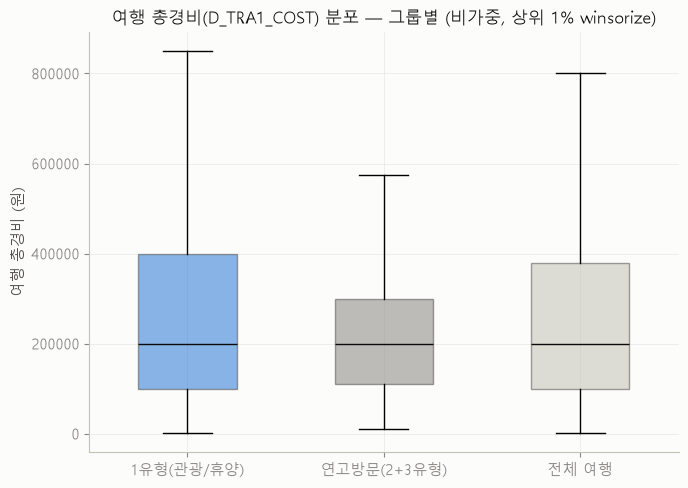

  1유형(관광/휴양): n=18,447, 평균=329,908, 중앙값=200,000
  연고방문(2+3유형): n=3,689, 평균=245,132, 중앙값=200,000
  전체 여행: n=22,729, 평균=314,268, 중앙값=200,000
1인 지출비용 0원(무비용) 비율: 1유형(관광/휴양)=0.0%, 연고방문(2+3유형)=0.0%, 전체 여행=0.0%


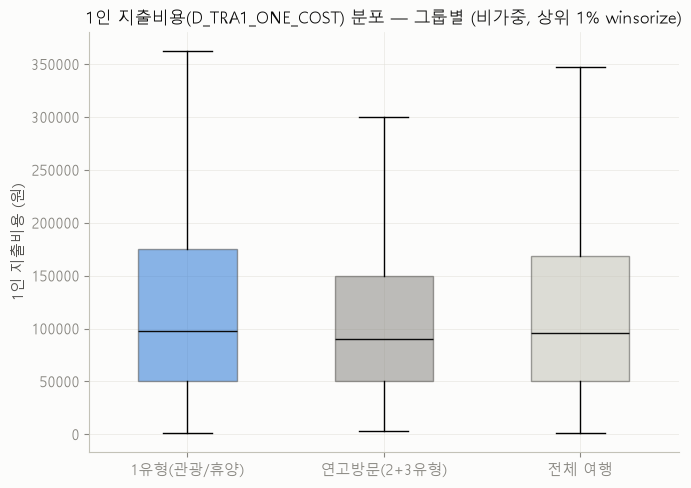

  1유형(관광/휴양): n=18,447, 평균=141,388, 중앙값=97,500
  연고방문(2+3유형): n=3,689, 평균=116,256, 중앙값=90,000
  전체 여행: n=22,729, 평균=137,577, 중앙값=95,700


In [25]:
# 총경비(D_TRA1_COST), 1인지출비용(D_TRA1_ONE_COST) — 그룹별 box plot (비가중)
# 연고방문은 무비용(가족집 체류 등) 응답이 섞여 log축이 0을 지워버릴 수 있어, log 대신 상위 1% winsorize로 이상치만 완화한다.
assert_allowed(["D_TRA1_COST", "D_TRA1_ONE_COST"])


def winsorize_upper(arr, pct=0.99):
    cap = np.quantile(arr, pct)
    return np.clip(arr, None, cap)


for col, label, unit in [("D_TRA1_COST", "여행 총경비", "원"), ("D_TRA1_ONE_COST", "1인 지출비용", "원")]:
    zero_share = {name: (d[col].dropna() == 0).mean() * 100 for name, d in groups2.items()}
    print(f"{label} 0원(무비용) 비율: " + ", ".join(f"{k}={v:.1f}%" for k, v in zero_share.items()))
    arrays = raw_group_arrays(groups2, col)
    arrays_w = {k: winsorize_upper(v) for k, v in arrays.items()}
    plot_box(arrays_w, f"{label}({col}) 분포 — 그룹별 (비가중, 상위 1% winsorize)", f"{label} ({unit})")

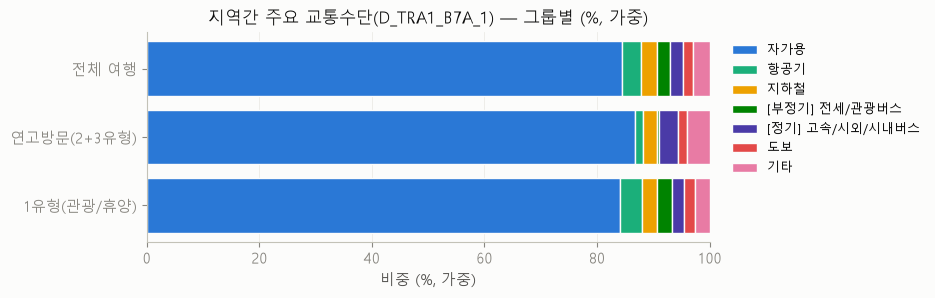

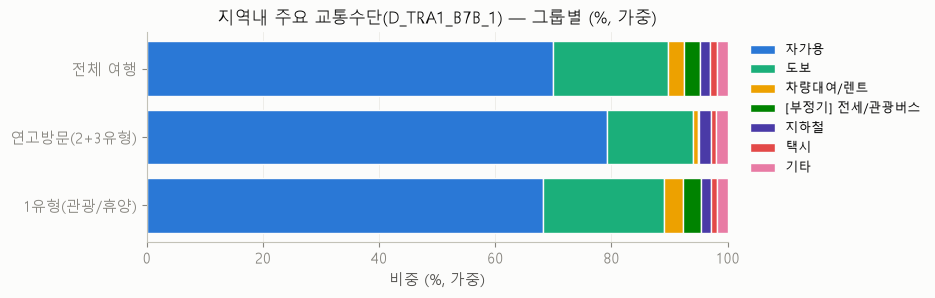

In [26]:
# 주요 교통수단(지역간 D_TRA1_B7A_1, 지역내 D_TRA1_B7B_1) — 그룹별 100% 누적 막대 (가중)
assert_allowed(["D_TRA1_B7A_1", "D_TRA1_B7B_1"])
b7a_by_group = {name: weighted_value_counts(d, "D_TRA1_B7A_1") for name, d in groups2.items()}
plot_stacked100(b7a_by_group, "지역간 주요 교통수단(D_TRA1_B7A_1) — 그룹별 (%, 가중)", top_n=6)

b7b_by_group = {name: weighted_value_counts(d, "D_TRA1_B7B_1") for name, d in groups2.items()}
plot_stacked100(b7b_by_group, "지역내 주요 교통수단(D_TRA1_B7B_1) — 그룹별 (%, 가중)", top_n=6)

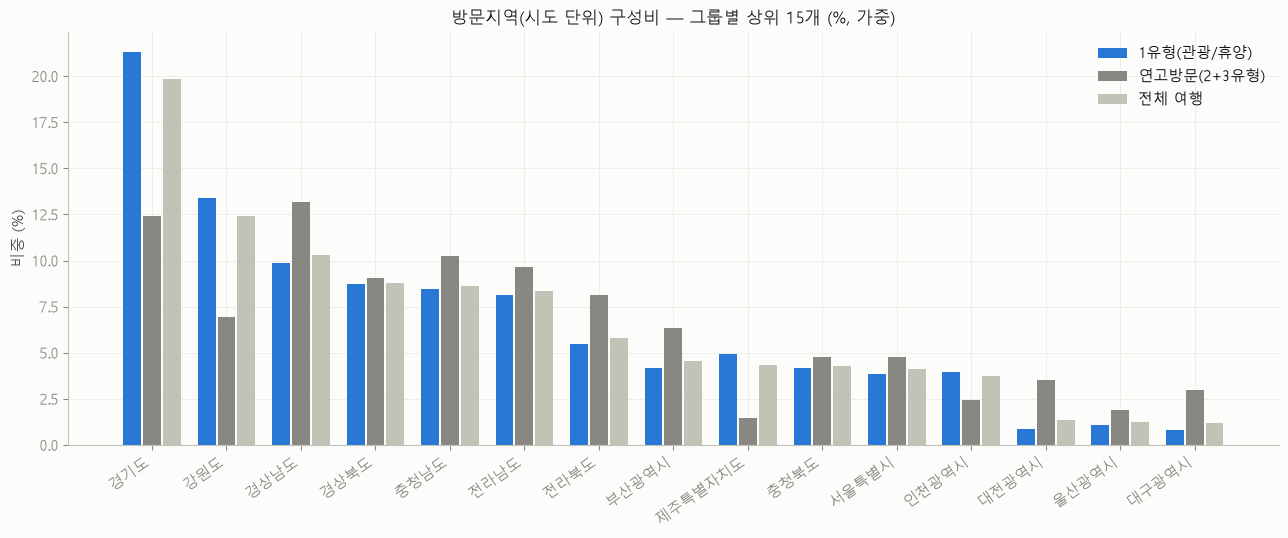

In [27]:
# 방문지역(시도 단위, D_TRA1_1_SPOT 디코딩) — 그룹별 상위 시도 막대 (가중)
assert_allowed("D_TRA1_1_SPOT")
sido_by_group = {}
for name, d in groups2.items():
    s = decode_spot(d["D_TRA1_1_SPOT"], "sido")
    w = pd.DataFrame({"cat": s, "w": d[WEIGHT_COL]}).dropna(subset=["cat"]).groupby("cat")["w"].sum()
    sido_by_group[name] = (w / w.sum() * 100).sort_values(ascending=False)

top_sido = list(sido_by_group["전체 여행"].sort_values(ascending=False).index[:15])
plot_grouped_bars(sido_by_group, "방문지역(시도 단위) 구성비 — 그룹별 상위 15개 (%, 가중)",
                   ylabel="비중 (%)", cat_order=top_sido, figsize=(13, 5.5))

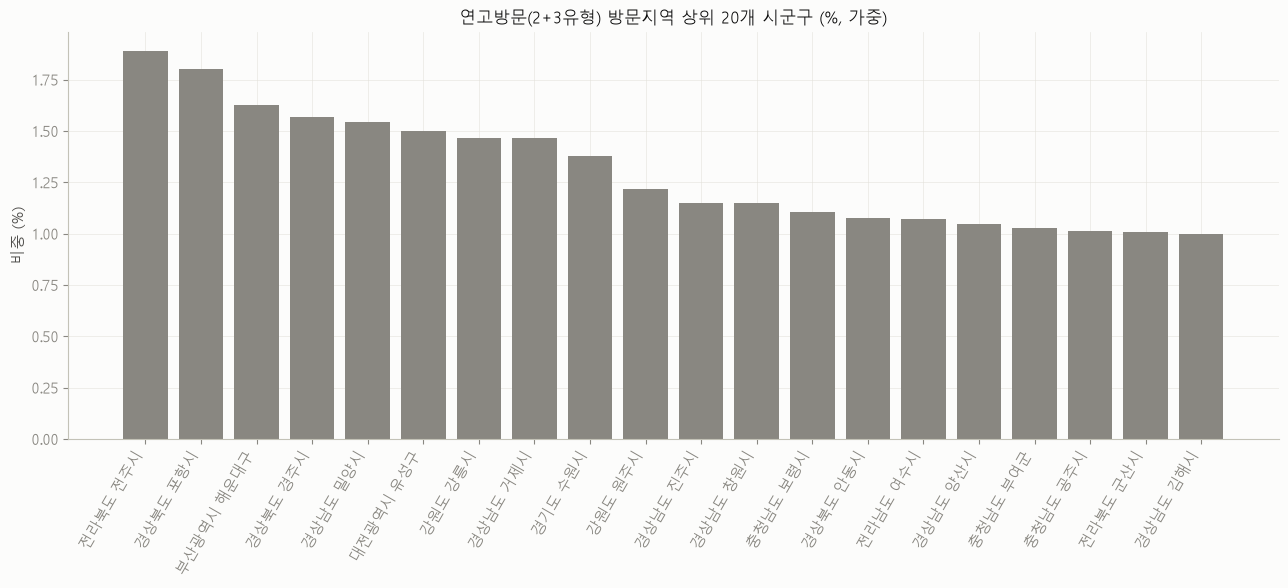

In [28]:
# 방문지역(시군구 단위) — 연고방문 그룹의 상위 20개 시군구 (가중)
# ※ 인구감소지역과의 중첩 여부는 본 노트북 범위 밖(참고용 파일 data/raw/pop_decline_danger/pop_decline_danger_region.csv만 존재), 언급만 하고 별도 분석하지 않음
sigungu_g2 = decode_spot(g2["D_TRA1_1_SPOT"], "sigungu")
w_sigungu = pd.DataFrame({"cat": sigungu_g2, "w": g2[WEIGHT_COL]}).dropna(subset=["cat"]).groupby("cat")["w"].sum()
sigungu_share = (w_sigungu / w_sigungu.sum() * 100).sort_values(ascending=False).head(20)
plot_bar(sigungu_share, "연고방문(2+3유형) 방문지역 상위 20개 시군구 (%, 가중)", ylabel="비중 (%)",
         figsize=(13, 6), xrotation=60)

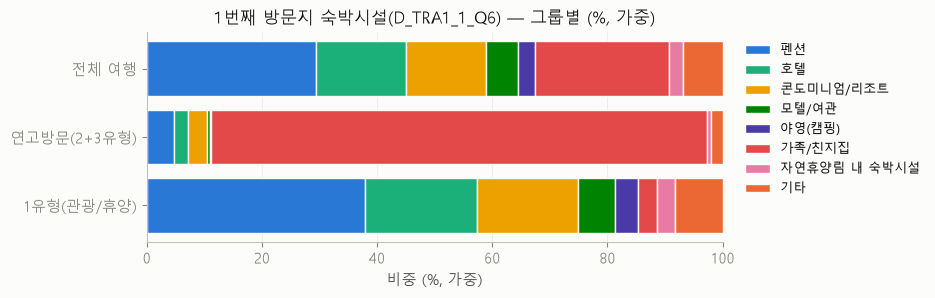

  1유형(관광/휴양): 가족/친지집 = 3.3%
  연고방문(2+3유형): 가족/친지집 = 86.0%
  전체 여행: 가족/친지집 = 23.3%


In [29]:
# 숙박시설(D_TRA1_1_Q6) — 그룹별 100% 누적 막대 (가중)
# 핵심 확인 포인트: "가족/친지집" 비중이 연고방문 그룹에서 두드러지는지
assert_allowed("D_TRA1_1_Q6")
q6_by_group = {name: weighted_value_counts(d, "D_TRA1_1_Q6") for name, d in groups2.items()}
plot_stacked100(q6_by_group, "1번째 방문지 숙박시설(D_TRA1_1_Q6) — 그룹별 (%, 가중)", top_n=7)

for name, s in q6_by_group.items():
    print(f"  {name}: 가족/친지집 = {s.get('가족/친지집', 0):.1f}%")

**해석**: 연고방문은 가족/친지집 숙박 비중이 높고 총경비·1인지출비용이 낮은 경향이 뚜렷하다면, 이는 "사람은 오는데 돈은 지역에 남지 않는" 구조를 데이터로 뒷받침한다 — `연고관광_purpose.md`가 지적한 문제의식과 직결되는 대목이다. 방문 시기가 명절월에 집중되는지, 방문지역이 인구감소지역과 겹치는지도 정책 타겟팅의 근거가 된다.

## 3. 연고여행의 특징 분석 (심층분석)

2유형에 해당하는 사람 중 해당 조사회차 동안 다른 유형(1·3·4·5유형)의 여행 이력이 전혀 없는 표본만 골라 분석함으로써 데이터의 신뢰성을 확보한다. **순수 1유형** 및 **전체 여행** 표본과 병기 비교한다.

In [30]:
assert_allowed(SA1_COLS)

pure2_mask = (base["D_TRA1_CASE"] == 2) & (base["SA1_1"] == 0) & (base["SA1_3"] == 0) & (base["SA1_4"] == 0) & (base["SA1_5"] == 0)
pure1_mask = (base["D_TRA1_CASE"] == 1) & (base["SA1_2"] == 0) & (base["SA1_3"] == 0) & (base["SA1_4"] == 0) & (base["SA1_5"] == 0)

pure2 = base[pure2_mask]   # 순수 2유형(연고여행) 표본
pure1 = base[pure1_mask]   # 순수 1유형 표본
all_trips = base           # 전체 여행 표본

groups3 = {"순수 2유형(연고여행)": pure2, "순수 1유형": pure1, "전체 여행": all_trips}

n_table3 = pd.DataFrame({
    "비가중 N": {k: len(v) for k, v in groups3.items()},
    "가중 합계": {k: v[WEIGHT_COL].sum() for k, v in groups3.items()},
})
print(n_table3)

              비가중 N         가중 합계
순수 2유형(연고여행)   3669  3.477779e+07
순수 1유형        18221  1.962351e+08
전체 여행         22729  2.393125e+08


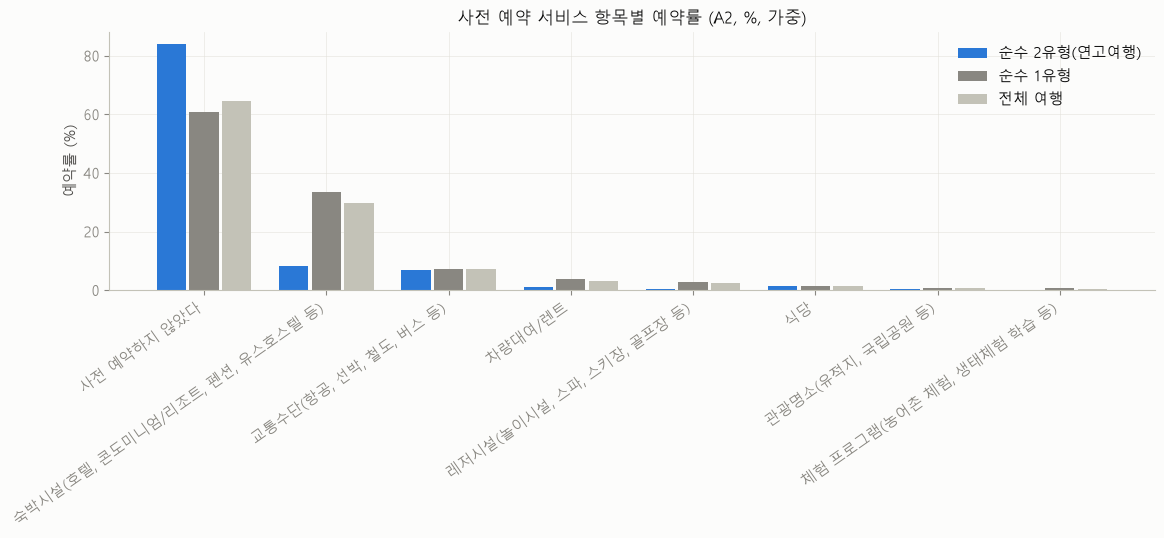

In [31]:
# 사전 예약 서비스 여부(A2_1~A2_11) — 항목별 예약률 (3그룹, 가중)
A2_COLS = [c for c in codebook["col_name"] if re.match(r"^A2_\d+$", str(c))]
assert_allowed(A2_COLS)
a2_by_group = {name: weighted_multi_ratio(d, A2_COLS) for name, d in groups3.items()}
plot_grouped_bars(a2_by_group, "사전 예약 서비스 항목별 예약률 (A2, %, 가중)", ylabel="예약률 (%)",
                   cat_order=list(a2_by_group["전체 여행"].sort_values(ascending=False).index), figsize=(12, 5.5))

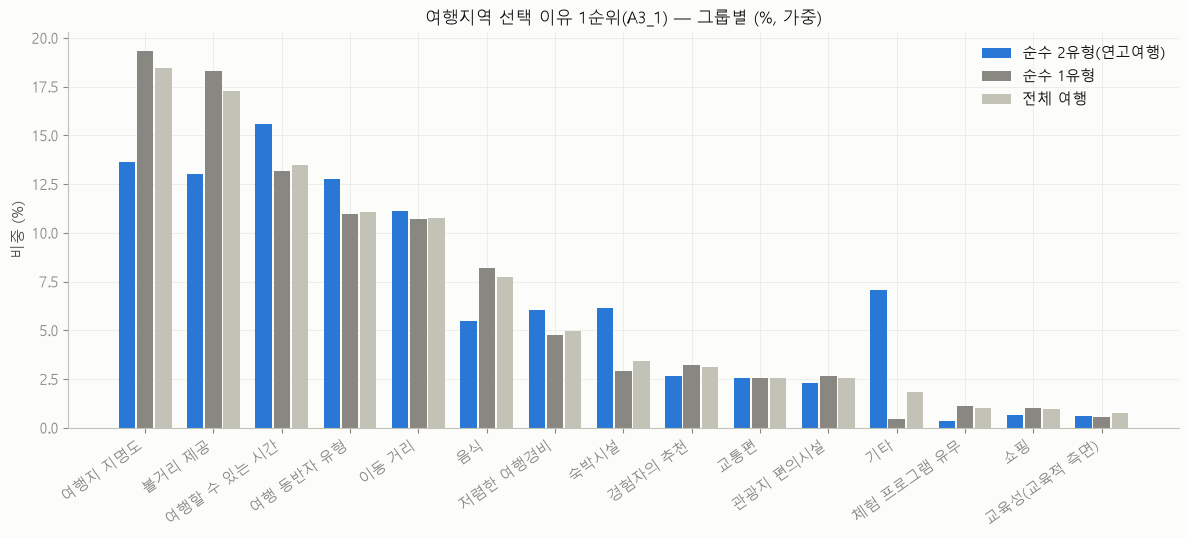

In [32]:
# 여행지역 선택 이유 1순위(A3_1) — 그룹별 비율 (3그룹, 가중)
assert_allowed("A3_1")
a3_by_group = {name: weighted_value_counts(d, "A3_1") for name, d in groups3.items()}
plot_grouped_bars(a3_by_group, "여행지역 선택 이유 1순위(A3_1) — 그룹별 (%, 가중)", ylabel="비중 (%)",
                   cat_order=list(a3_by_group["전체 여행"].sort_values(ascending=False).index), figsize=(12, 5.5))

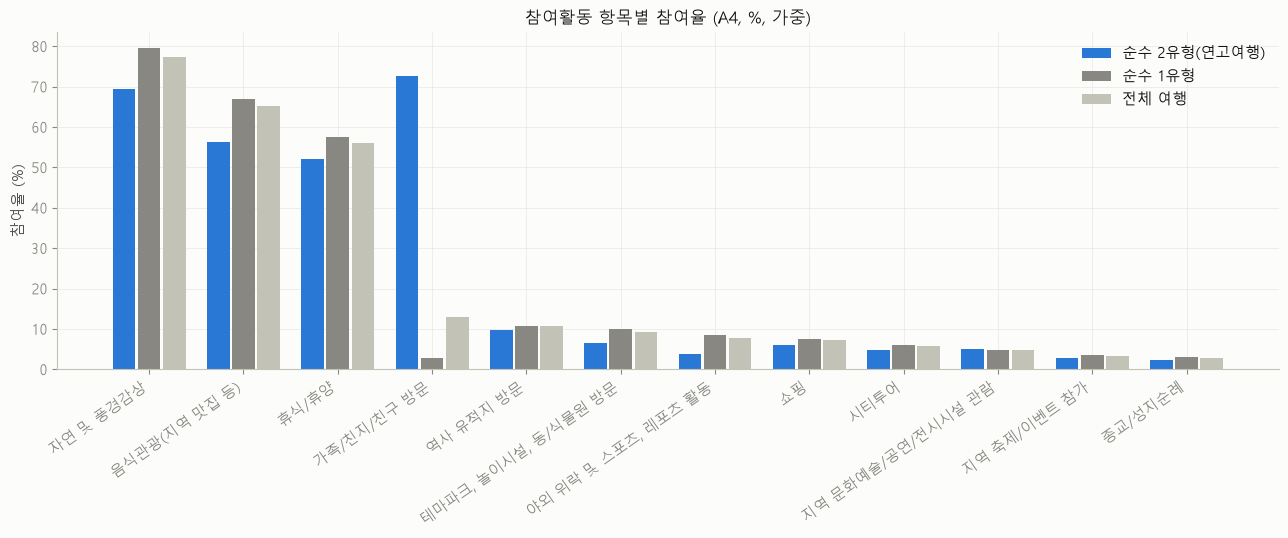

In [33]:
# 참여활동(A4_1~A4_21) — 활동유형별 참여율 (3그룹, 가중)
A4_MULTI_COLS = [c for c in codebook["col_name"] if re.match(r"^A4_\d+$", str(c))]
assert_allowed(A4_MULTI_COLS)
a4_by_group = {name: weighted_multi_ratio(d, A4_MULTI_COLS) for name, d in groups3.items()}
plot_grouped_bars(a4_by_group, "참여활동 항목별 참여율 (A4, %, 가중)", ylabel="참여율 (%)",
                   cat_order=list(a4_by_group["전체 여행"].sort_values(ascending=False).index), top_n=12, figsize=(13, 5.5))

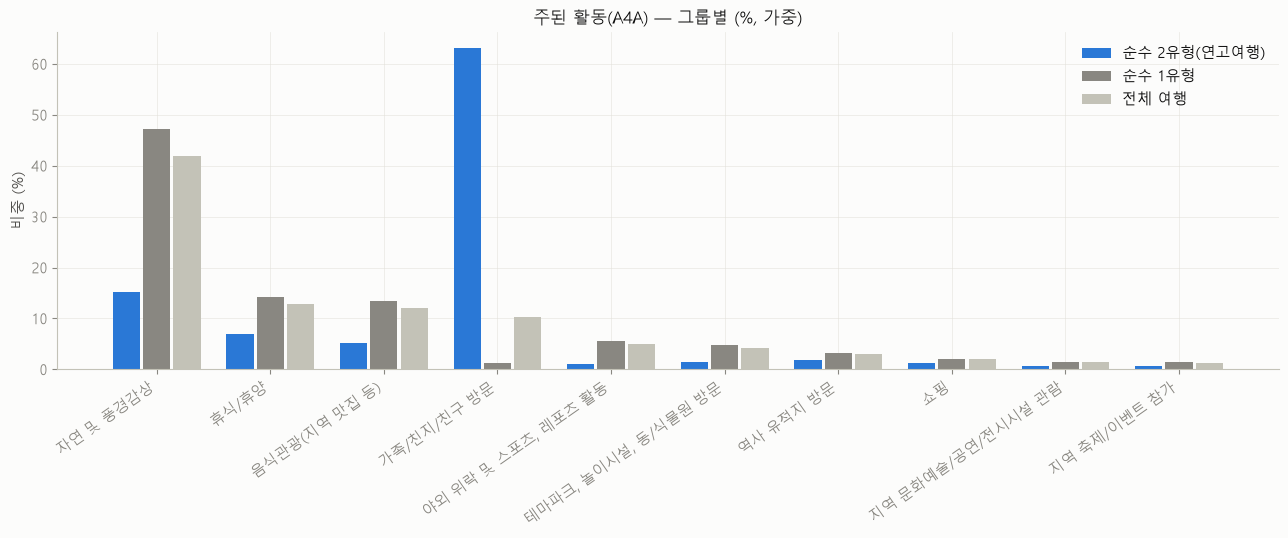

In [34]:
# 주된 활동(A4A) — 단일선택 분포 (3그룹, 가중)
assert_allowed("A4A")
a4a_by_group = {name: weighted_value_counts(d, "A4A") for name, d in groups3.items()}
plot_grouped_bars(a4a_by_group, "주된 활동(A4A) — 그룹별 (%, 가중)", ylabel="비중 (%)",
                   cat_order=list(a4a_by_group["전체 여행"].sort_values(ascending=False).index), top_n=10, figsize=(13, 5.5))

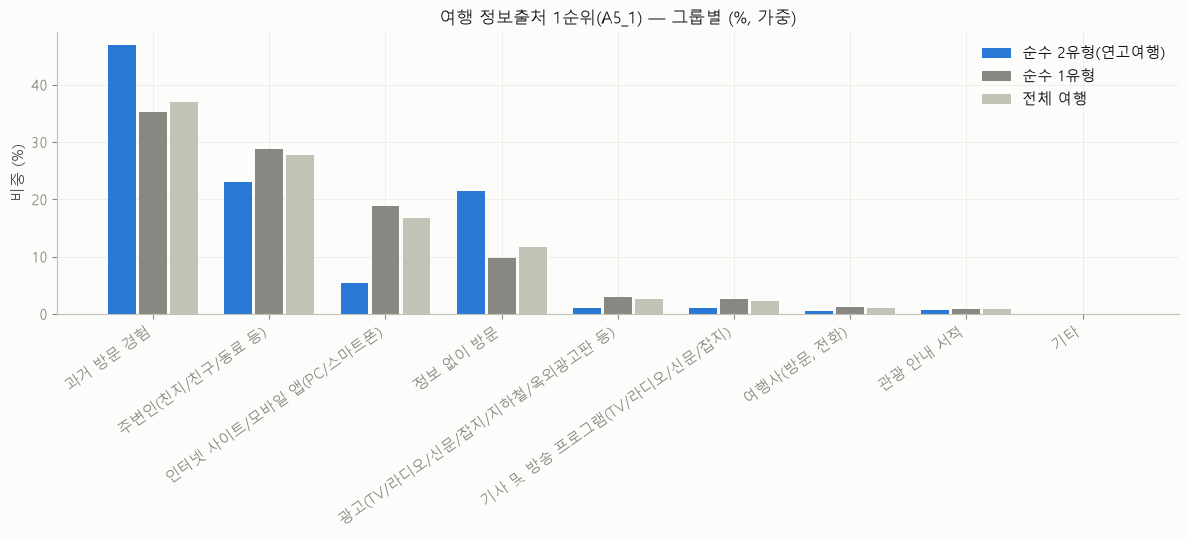

In [35]:
# 여행 정보출처 1순위(A5_1) — 그룹별 (3그룹, 가중) — "과거 방문 경험"·"주변인" 비중 확인 포인트
assert_allowed("A5_1")
a5_by_group = {name: weighted_value_counts(d, "A5_1") for name, d in groups3.items()}
plot_grouped_bars(a5_by_group, "여행 정보출처 1순위(A5_1) — 그룹별 (%, 가중)", ylabel="비중 (%)",
                   cat_order=list(a5_by_group["전체 여행"].sort_values(ascending=False).index), figsize=(12, 5.5))

A5_1==1(인터넷/앱) 응답 N: {'순수 2유형(연고여행)': 187, '순수 1유형': 3140, '전체 여행': 3431}


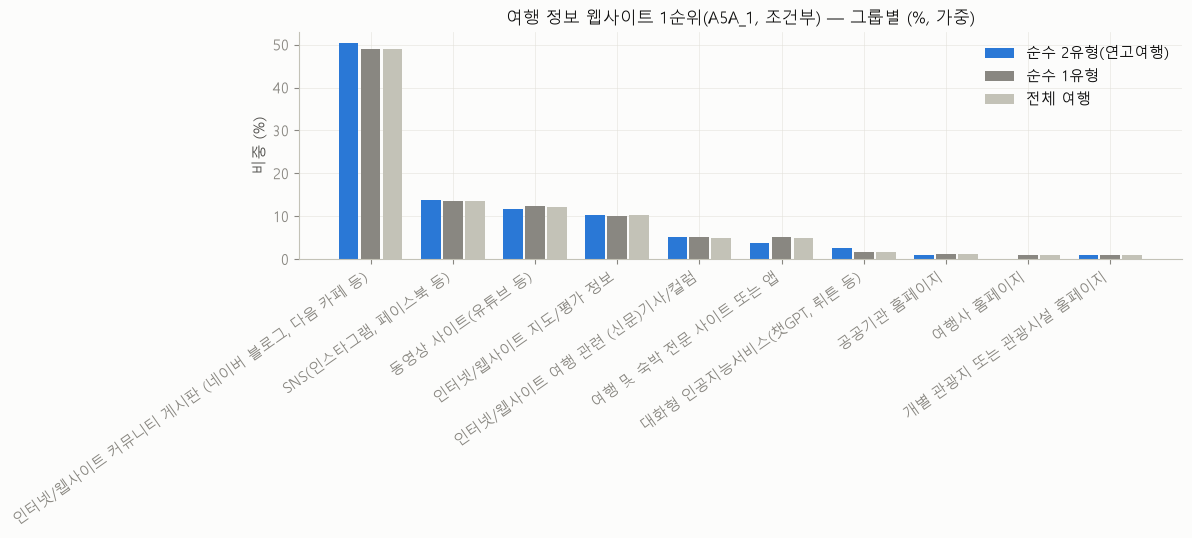

In [36]:
# 여행 정보 웹사이트 1순위(A5A_1, A5_1==1 인터넷/앱 응답자 대상 조건부 문항) — 그룹별 (가중)
assert_allowed("A5A_1")
groups3_web = {name: d[d["A5_1"] == 1] for name, d in groups3.items()}
print("A5_1==1(인터넷/앱) 응답 N:", {k: len(v) for k, v in groups3_web.items()})
a5a_by_group = {name: weighted_value_counts(d, "A5A_1") for name, d in groups3_web.items()}
plot_grouped_bars(a5a_by_group, "여행 정보 웹사이트 1순위(A5A_1, 조건부) — 그룹별 (%, 가중)", ylabel="비중 (%)",
                   cat_order=list(a5a_by_group["전체 여행"].sort_values(ascending=False).index), figsize=(12, 5.5))

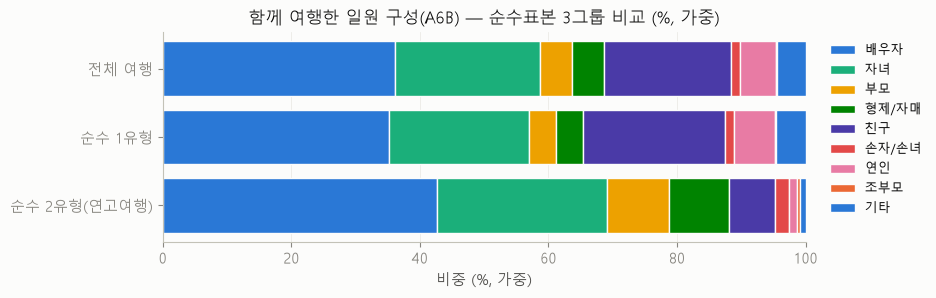

[2단계 연고방문(2+3유형) 그룹 구성비 대조]
label
배우자      42.637295
자녀       26.485969
부모        9.664388
형제/자매     9.259925
친구        7.268590
손자/손녀     2.049685
Name: WT_DOM, dtype: float64


In [37]:
# 함께 여행한 일원 구성(A6B_1~12) — 순수 2유형 표본 중심, 3그룹 비교 (가중, 2단계 G2 결과와 대조)
a6b_composition_3 = {name: weighted_multi_composition(d, A6B_COLS) for name, d in groups3.items()}
plot_stacked100(a6b_composition_3, "함께 여행한 일원 구성(A6B) — 순수표본 3그룹 비교 (%, 가중)", top_n=8)

print("[2단계 연고방문(2+3유형) 그룹 구성비 대조]")
print(a6b_composition["연고방문(2+3유형)"].head(6))

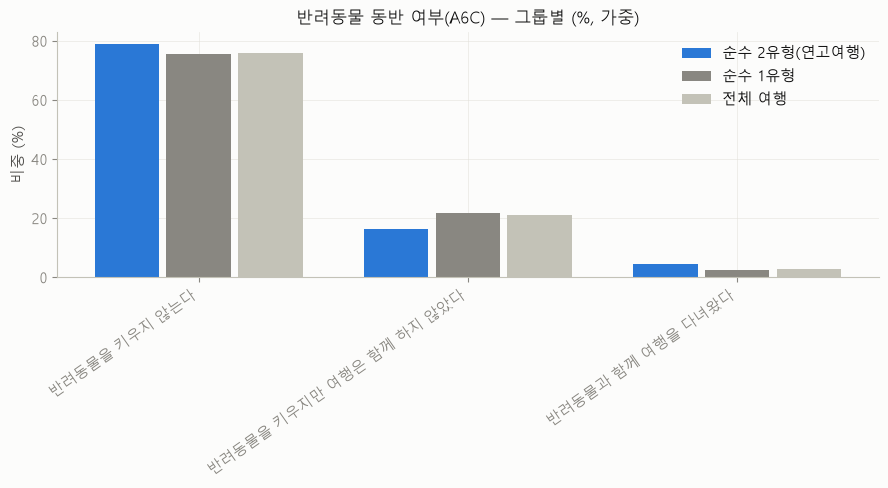

In [38]:
# 반려동물 동반 여부(A6C) — 그룹별 (3그룹, 가중)
assert_allowed("A6C")
a6c_by_group = {name: weighted_value_counts(d, "A6C") for name, d in groups3.items()}
plot_grouped_bars(a6c_by_group, "반려동물 동반 여부(A6C) — 그룹별 (%, 가중)", ylabel="비중 (%)", figsize=(9, 5))

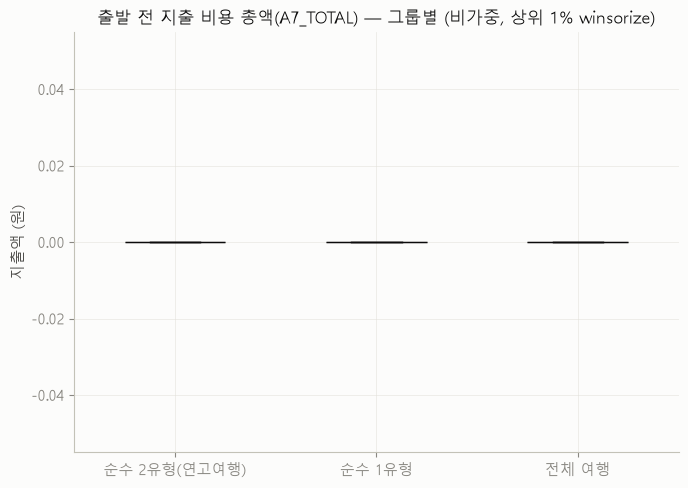

  순수 2유형(연고여행): n=3,669, 평균=6,858, 중앙값=0
  순수 1유형: n=18,221, 평균=8,945, 중앙값=0
  전체 여행: n=22,729, 평균=8,698, 중앙값=0


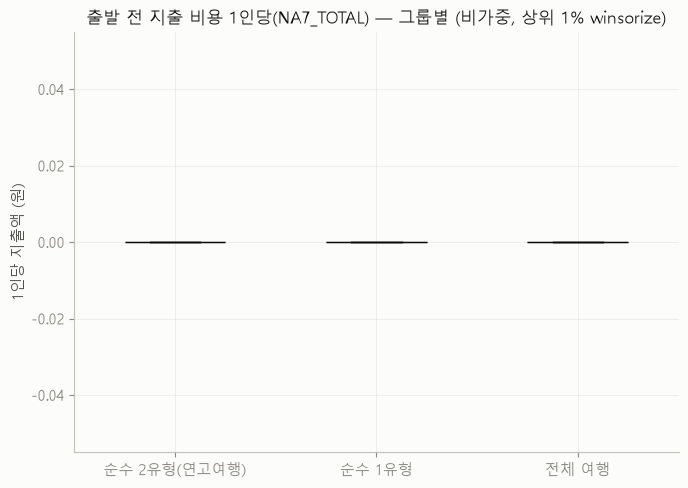

  순수 2유형(연고여행): n=3,669, 평균=3,027, 중앙값=0
  순수 1유형: n=18,221, 평균=3,088, 중앙값=0
  전체 여행: n=22,729, 평균=3,091, 중앙값=0


In [39]:
# 출발 전 지출 비용 총액(A7_TOTAL) / 1인당(NA7_TOTAL) — box plot (3그룹, 비가중)
assert_allowed(["A7_TOTAL", "NA7_TOTAL"])
plot_box({k: winsorize_upper(v) for k, v in raw_group_arrays(groups3, "A7_TOTAL").items()},
         "출발 전 지출 비용 총액(A7_TOTAL) — 그룹별 (비가중, 상위 1% winsorize)", "지출액 (원)")
plot_box({k: winsorize_upper(v) for k, v in raw_group_arrays(groups3, "NA7_TOTAL").items()},
         "출발 전 지출 비용 1인당(NA7_TOTAL) — 그룹별 (비가중, 상위 1% winsorize)", "1인당 지출액 (원)")

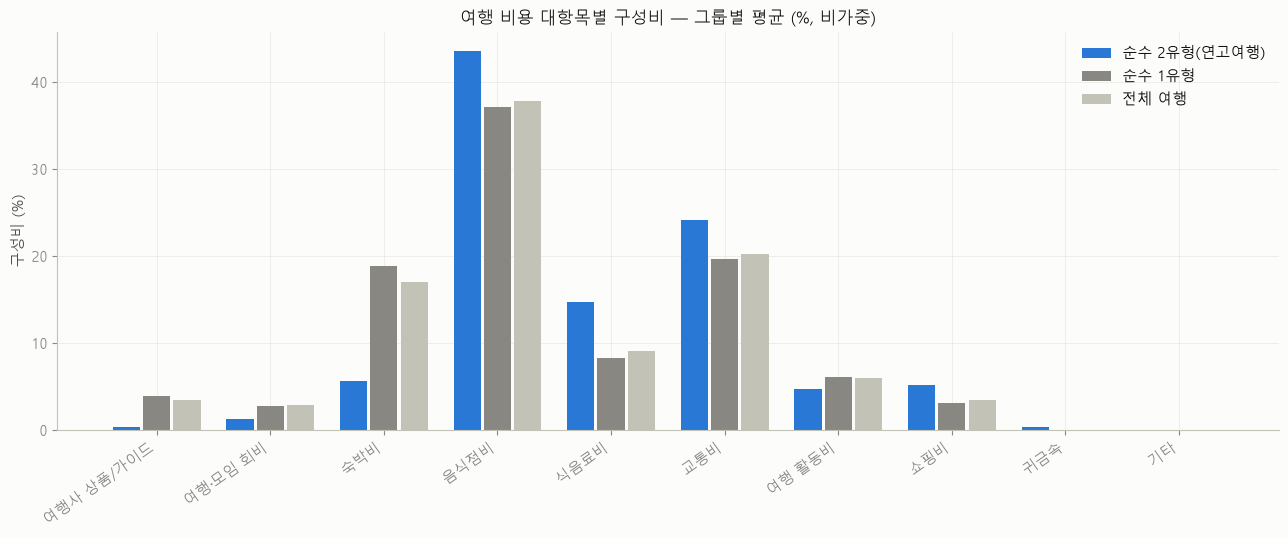

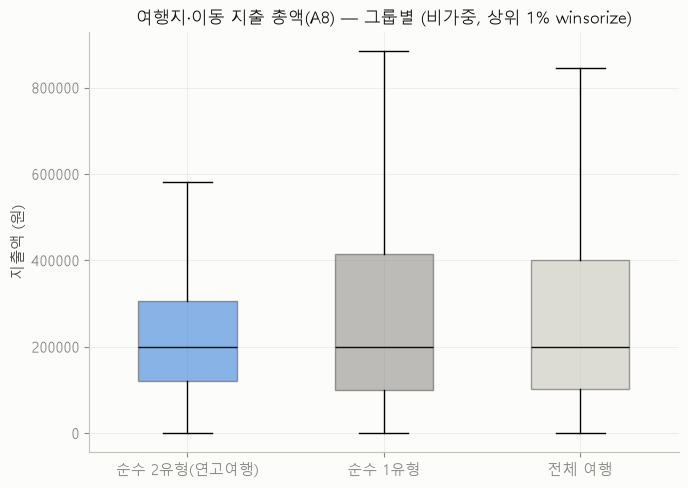

  순수 2유형(연고여행): n=3,669, 평균=251,741, 중앙값=200,000
  순수 1유형: n=18,221, 평균=341,958, 중앙값=200,000
  전체 여행: n=22,729, 평균=325,663, 중앙값=200,000


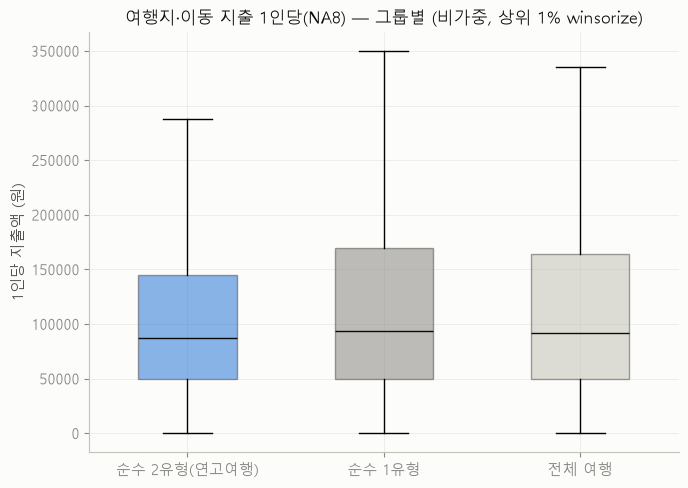

  순수 2유형(연고여행): n=3,669, 평균=112,811, 중앙값=87,000
  순수 1유형: n=18,221, 평균=138,013, 중앙값=94,000
  전체 여행: n=22,729, 평균=134,153, 중앙값=91,667


In [40]:
# 여행 비용 대항목별 구성비(A8A~A8J) — 그룹별 평균 구성비(비가중 평균) + 총지출(A8)/1인당(NA8) box plot (3그룹, 비가중)
A8_MAJOR_COLS = ["A8A", "A8B", "A8C", "A8D", "A8E", "A8F", "A8G", "A8H", "A8I", "A8J"]
A8_MAJOR_LABELS = {
    "A8A": "여행사 상품/가이드", "A8B": "여행·모임 회비", "A8C": "숙박비", "A8D": "음식점비",
    "A8E": "식음료비", "A8F": "교통비", "A8G": "여행 활동비", "A8H": "쇼핑비",
    "A8I": "귀금속", "A8J": "기타",
}
assert_allowed(A8_MAJOR_COLS + ["A8", "NA8"])

a8_share_by_group = {}
for name, d in groups3.items():
    means = d[A8_MAJOR_COLS].fillna(0).mean()
    share = means / means.sum() * 100
    a8_share_by_group[name] = share.rename(index=A8_MAJOR_LABELS)

plot_grouped_bars(a8_share_by_group, "여행 비용 대항목별 구성비 — 그룹별 평균 (%, 비가중)", ylabel="구성비 (%)",
                   cat_order=list(A8_MAJOR_LABELS.values()), figsize=(13, 5.5))

plot_box({k: winsorize_upper(v) for k, v in raw_group_arrays(groups3, "A8").items()},
         "여행지·이동 지출 총액(A8) — 그룹별 (비가중, 상위 1% winsorize)", "지출액 (원)")
plot_box({k: winsorize_upper(v) for k, v in raw_group_arrays(groups3, "NA8").items()},
         "여행지·이동 지출 1인당(NA8) — 그룹별 (비가중, 상위 1% winsorize)", "1인당 지출액 (원)")

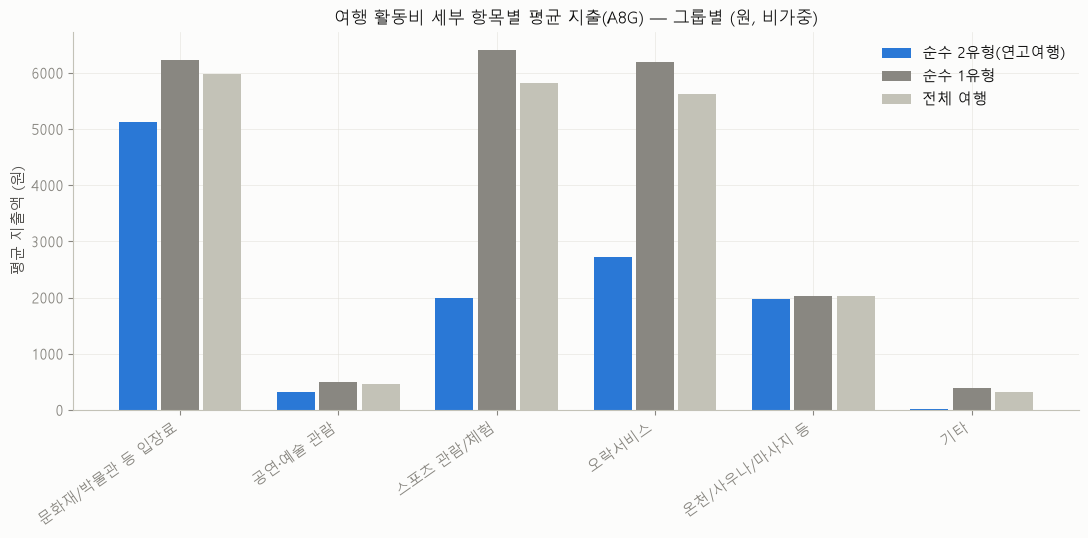

In [41]:
# 여행 활동비 세부 지출(A8G_1~6) — 그룹별 평균 지출 (비가중)
A8G_SUB_COLS = [f"A8G_{i}" for i in range(1, 7)]
A8G_SUB_LABELS = {
    "A8G_1": "문화재/박물관 등 입장료", "A8G_2": "공연·예술 관람", "A8G_3": "스포츠 관람/체험",
    "A8G_4": "오락서비스", "A8G_5": "온천/사우나/마사지 등", "A8G_6": "기타",
}
assert_allowed(A8G_SUB_COLS)
a8g_mean_by_group = {name: d[A8G_SUB_COLS].fillna(0).mean().rename(index=A8G_SUB_LABELS) for name, d in groups3.items()}
plot_grouped_bars(a8g_mean_by_group, "여행 활동비 세부 항목별 평균 지출(A8G) — 그룹별 (원, 비가중)", ylabel="평균 지출액 (원)",
                   cat_order=list(A8G_SUB_LABELS.values()), figsize=(11, 5.5))

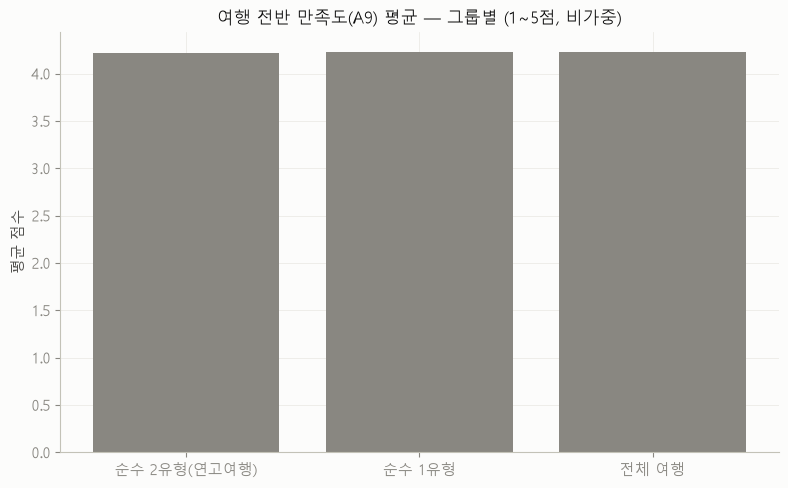

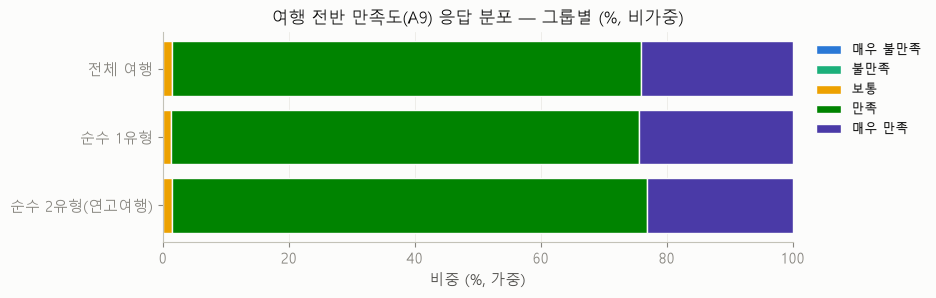

In [42]:
# 여행 만족도(A9) — 그룹별 평균(비가중) + 분포 비교
assert_allowed("A9")
a9_mean = group_mean_series(groups3, "A9")
plot_bar(a9_mean, "여행 전반 만족도(A9) 평균 — 그룹별 (1~5점, 비가중)", ylabel="평균 점수", figsize=(8, 5))

a9_dist = {name: weighted_value_counts(d.assign(_w=1.0), "A9", weight_col="_w") for name, d in groups3.items()}
satisfaction_order = ["매우 불만족", "불만족", "보통", "만족", "매우 만족"]
plot_stacked100(a9_dist, "여행 전반 만족도(A9) 응답 분포 — 그룹별 (%, 비가중)", cat_order=satisfaction_order)

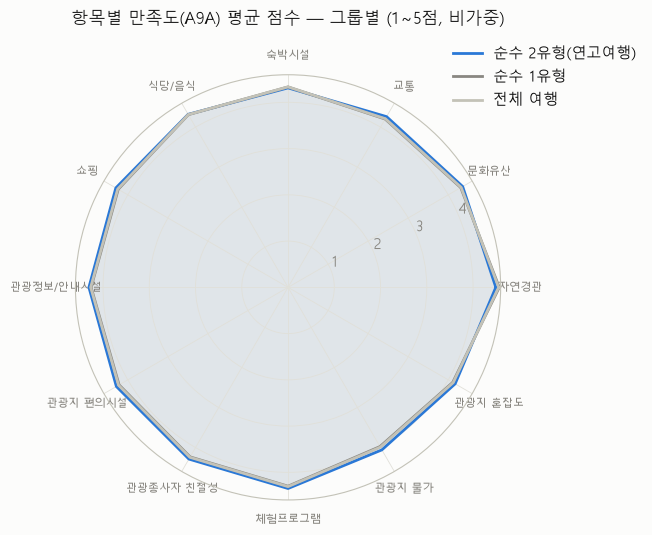

In [43]:
# 항목별 만족도(A9A_1~12) — 그룹별 평균 점수 레이더 차트 (비가중, 9=경험 없음은 결측 처리)
A9A_COLS = [f"A9A_{i}" for i in range(1, 13)]
A9A_LABELS = {
    "A9A_1": "자연경관", "A9A_2": "문화유산", "A9A_3": "교통", "A9A_4": "숙박시설",
    "A9A_5": "식당/음식", "A9A_6": "쇼핑", "A9A_7": "관광정보/안내시설", "A9A_8": "관광지 편의시설",
    "A9A_9": "관광종사자 친절성", "A9A_10": "체험프로그램", "A9A_11": "관광지 물가", "A9A_12": "관광지 혼잡도",
}
assert_allowed(A9A_COLS)

a9a_clean = {name: d[A9A_COLS].replace(9, np.nan) for name, d in groups3.items()}
a9a_mean_by_group = {name: d.mean().rename(index=A9A_LABELS) for name, d in a9a_clean.items()}
plot_radar(a9a_mean_by_group, "항목별 만족도(A9A) 평균 점수 — 그룹별 (1~5점, 비가중)", cat_order=list(A9A_LABELS.values()))

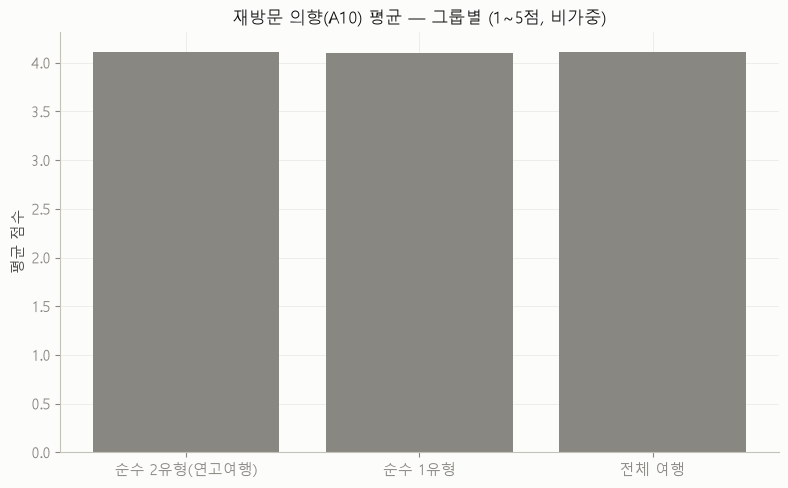

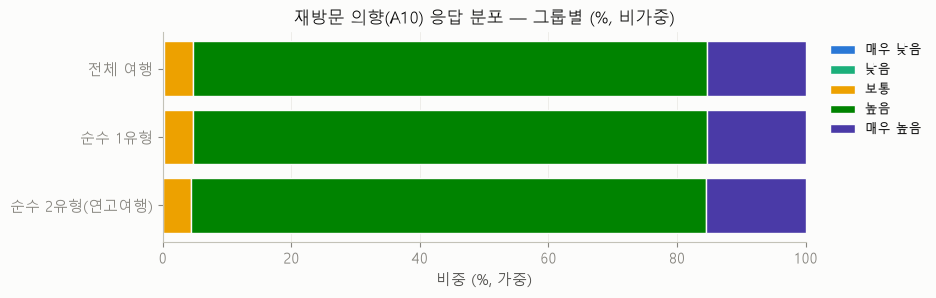

In [44]:
# 재방문 의향(A10) — 그룹별 평균(비가중) + 분포
assert_allowed("A10")
a10_mean = group_mean_series(groups3, "A10")
plot_bar(a10_mean, "재방문 의향(A10) 평균 — 그룹별 (1~5점, 비가중)", ylabel="평균 점수", figsize=(8, 5))

a10_dist = {name: weighted_value_counts(d.assign(_w=1.0), "A10", weight_col="_w") for name, d in groups3.items()}
revisit_order = ["매우 낮음", "낮음", "보통", "높음", "매우 높음"]
plot_stacked100(a10_dist, "재방문 의향(A10) 응답 분포 — 그룹별 (%, 비가중)", cat_order=revisit_order)

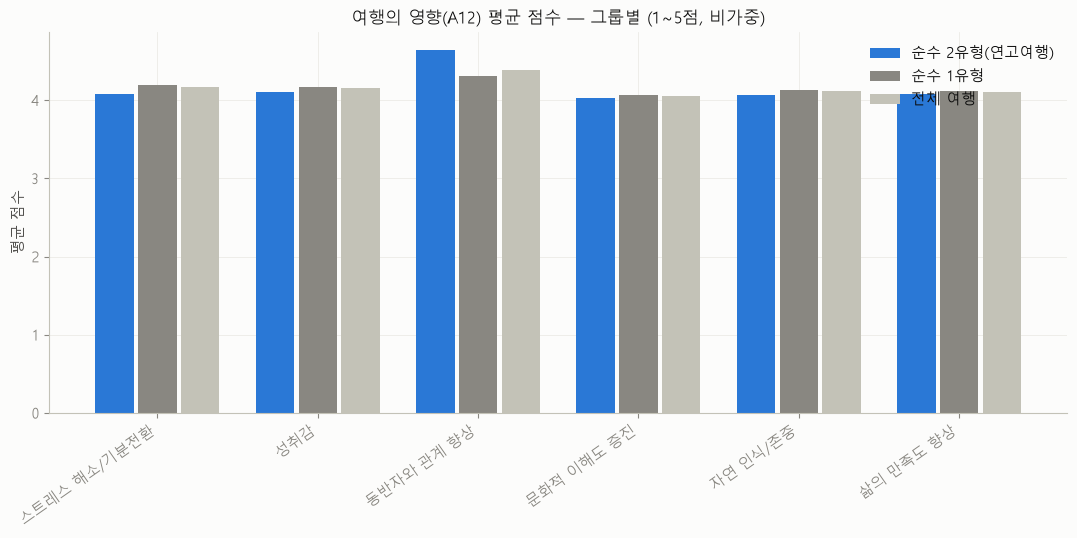

In [45]:
# 여행의 영향(A12_1~6) — 그룹별 평균 점수 (비가중)
A12_COLS = [f"A12_{i}" for i in range(1, 7)]
A12_LABELS = {
    "A12_1": "스트레스 해소/기분전환", "A12_2": "성취감", "A12_3": "동반자와 관계 향상",
    "A12_4": "문화적 이해도 증진", "A12_5": "자연 인식/존중", "A12_6": "삶의 만족도 향상",
}
assert_allowed(A12_COLS)
a12_mean_by_group = {name: d[A12_COLS].mean().rename(index=A12_LABELS) for name, d in groups3.items()}
plot_grouped_bars(a12_mean_by_group, "여행의 영향(A12) 평균 점수 — 그룹별 (1~5점, 비가중)", ylabel="평균 점수",
                   cat_order=list(A12_LABELS.values()), figsize=(11, 5.5))

**해석**: 순수 2유형(연고여행)이 순수 1유형·전체 여행보다 사전예약률·활동참여율·지출액이 낮으면서도 만족도·재방문의향은 크게 뒤지지 않는다면, "이미 만족스럽게 반복 방문하지만 소비로 이어지지 않는" 집단이라는 정책 가설이 뒷받침된다. 여행지역 선택 이유·정보출처에서 "주변인"·"과거 방문 경험" 비중이 높다면 신규 마케팅보다 기존 관계망을 활용한 전환 유인(바우처 등) 설계가 더 효과적이라는 근거가 된다.

## 4. 핵심 지표 계약 및 재현성 산출물

아래 셀은 분석 결과의 핵심 수치와 정의를 `key_metrics.json`으로 내보낸다. 자동 검증은 이 파일을 승인된 기준값과 비교하며 원본 노트북이나 원자료를 덮어쓰지 않는다.

In [46]:
import hashlib
import json
import os
from pathlib import Path


def contract_metric(value, unit, population, weighted, method):
    """Build one serializable key-metric contract entry.

    Args:
        value: Numeric metric value.
        unit: Human-readable measurement unit.
        population: Population or comparison group represented.
        weighted: Whether WT_DOM was applied.
        method: Reproducible calculation description.

    Returns:
        Dictionary containing the metric contract.
    """
    return {
        "value": float(value),
        "unit": unit,
        "population": population,
        "weighted": weighted,
        "method": method,
    }


def file_sha256(path):
    """Calculate a SHA-256 digest without loading the file at once.

    Args:
        path: File path to hash.

    Returns:
        Lowercase hexadecimal digest.
    """
    digest = hashlib.sha256()
    with Path(path).open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


type_2_internal_share = (
    weighted_trip_volume[TYPE_LABELS[2]] / yeongo_total * 100
)
type_3_internal_share = (
    weighted_trip_volume[TYPE_LABELS[3]] / yeongo_total * 100
)
KEY_METRICS = {
    "schema_version": 1,
    "data_file": SAV_PATH,
    "data_sha256": file_sha256(SAV_PATH),
    "metrics": {
        "source_row_count": contract_metric(
            len(df), "rows", "2025 국민여행조사 국내여행 원자료", False, "len(df)"
        ),
        "base_row_count": contract_metric(
            len(base), "rows", "D_TRA1_CHECK == 'Y'", False, "len(base)"
        ),
        "pure_type_1_count": contract_metric(
            len(pure1), "rows", "순수 1유형", False, "len(pure1)"
        ),
        "pure_type_2_count": contract_metric(
            len(pure2), "rows", "순수 2유형 연고여행", False, "len(pure2)"
        ),
        "total_weighted_trips": contract_metric(
            total_weighted_trips, "weighted trips", "전체 국내여행", True,
            "sum(WT_DOM * SA1_1..SA1_5)",
        ),
        "relationship_visit_share": contract_metric(
            yeongo_share, "percent", "전체 국내여행 중 유형 2·3", True,
            "weighted types 2+3 / weighted types 1..5 * 100",
        ),
        "type_2_share_within_relationship_visits": contract_metric(
            type_2_internal_share, "percent", "연고방문 유형 2·3", True,
            "weighted type 2 / weighted types 2+3 * 100",
        ),
        "type_3_share_within_relationship_visits": contract_metric(
            type_3_internal_share, "percent", "연고방문 유형 2·3", True,
            "weighted type 3 / weighted types 2+3 * 100",
        ),
        "pure_type_2_satisfaction_mean": contract_metric(
            a9_mean["순수 2유형(연고여행)"], "1–5 score", "순수 2유형", False,
            "arithmetic mean of A9 excluding missing values",
        ),
        "pure_type_2_revisit_mean": contract_metric(
            a10_mean["순수 2유형(연고여행)"], "1–5 score", "순수 2유형", False,
            "arithmetic mean of A10 excluding missing values",
        ),
    },
}

KEY_METRICS

{'schema_version': 1,
 'data_file': WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/data/raw/national_travel_survey/y2025/2025년_국민여행조사_국내여행.SAV'),
 'data_sha256': 'e367c69415ee99171f2114e6fdcd28e50b440384f93a9ab0116c2c8bae556b9e',
 'metrics': {'source_row_count': {'value': 52185.0,
   'unit': 'rows',
   'population': '2025 국민여행조사 국내여행 원자료',
   'weighted': False,
   'method': 'len(df)'},
  'base_row_count': {'value': 22729.0,
   'unit': 'rows',
   'population': "D_TRA1_CHECK == 'Y'",
   'weighted': False,
   'method': 'len(base)'},
  'pure_type_1_count': {'value': 18221.0,
   'unit': 'rows',
   'population': '순수 1유형',
   'weighted': False,
   'method': 'len(pure1)'},
  'pure_type_2_count': {'value': 3669.0,
   'unit': 'rows',
   'population': '순수 2유형 연고여행',
   'weighted': False,
   'method': 'len(pure2)'},
  'total_weighted_trips': {'value': 300909307.14263064,
   'unit': 'weighted trips',
   'population': '전체 국내여행',
   'weighted': True,
   'method': 'sum(WT_DOM * SA1_1..SA1